In [32]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [33]:
file_path = '/content/drive/My Drive/TÜ Andmeteadus MSc/Machine Learning I/Project/cgm.txt'
df = pd.read_csv(file_path, sep="|")
df.head()

,PtID,Period,DataDtTm,CGM
0,1,1. Baseline,11DEC17:23:59:25,172
1,1,1. Baseline,12DEC17:00:04:24,170
2,1,1. Baseline,12DEC17:00:09:24,167
3,1,1. Baseline,12DEC17:00:14:25,163
4,1,1. Baseline,12DEC17:00:19:25,160


In [34]:
#kuupäeva formaadi veerg
df['DataDtTm'] = pd.to_datetime(df['DataDtTm'], format='%d%b%y:%H:%M:%S')

#Sorteeri kindluse mõttes
df = df.sort_values(['PtID', 'DataDtTm'])

# Arvuta ajavahe järjestikuste mõõtmiste vahel
df['delta_min'] = df.groupby('PtID')['DataDtTm'].diff().dt.total_seconds() / 60

#  Kontrolli tüüpilist sammu
df['delta_min'].describe()


,delta_min
count,9.032067e+06
mean,5.393085e+00
std,3.098620e+02
min,4.500000e+00
25%,5.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,9.275909e+05


In [35]:
# Puuduvad väärtused
df['CGM'].isna().sum()

# Väärtuste vahemik
df['CGM'].describe()

# Eemalda või interpoleeri lüngad
df['CGM_interp'] = df.groupby('PtID')['CGM'].transform(lambda x: x.interpolate(limit=3))

print(df['CGM'].isna().sum())
print(df['CGM'].describe())

# Teisendus mg/dL → mmol/L
df['CGM_mmol'] = df['CGM'] / 18

# Märgi, kas väärtus on vahemikus 4–10 mmol/L
df['in_range'] = df['CGM_mmol'].between(4, 10)


0
count    9.032235e+06
mean     1.604207e+02
std      6.120771e+01
min      3.900000e+01
25%      1.160000e+02
50%      1.480000e+02
75%      1.930000e+02
max      4.010000e+02
Name: CGM, dtype: float64


In [36]:
df

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range
0,1,1. Baseline,2017-12-11 23:59:25,172,NaN,172,9.555556,True
1,1,1. Baseline,2017-12-12 00:04:24,170,4.983333,170,9.444444,True
2,1,1. Baseline,2017-12-12 00:09:24,167,5.000000,167,9.277778,True
3,1,1. Baseline,2017-12-12 00:14:25,163,5.016667,163,9.055556,True
4,1,1. Baseline,2017-12-12 00:19:25,160,5.000000,160,8.888889,True
...,...,...,...,...,...,...,...,...
4292120,171,2. Post Randomization,2018-10-24 08:50:04,174,5.000000,174,9.666667,True
4292121,171,2. Post Randomization,2018-10-24 08:55:04,192,5.000000,192,10.666667,False
4292122,171,2. Post Randomization,2018-10-24 09:00:04,189,5.000000,189,10.500000,False
4292123,171,2. Post Randomization,2018-10-24 09:05:04,183,5.000000,183,10.166667,False


In [31]:
print("Patsientide arv:", df['PtID'].nunique())
print("Patsiendinimekiri:")
print(sorted(df['PtID'].unique()))


Patsientide arv: 168
Patsiendinimekiri:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np

# Clustering

* **EPISOODI KLASTER** = "Kuidas just SEE konkreetne söögikord välja nägi?"
* **PATSIENDI KLASTER** = "Milline on selle inimese tüüpiline keskmine reaktsioon üldiselt, mitte ühe episoodi puhul?"

Soovitatud klasterdajad:
- K-Means
- GMM
- HDBSCAN
- Spectral clustering

In [27]:
df

,PtID,Period,DataDtTm,CGM,delta_min,CGM_interp,CGM_mmol,in_range
0,1,1. Baseline,2017-12-11 23:59:25,172,NaN,172,9.555556,True
1,1,1. Baseline,2017-12-12 00:04:24,170,4.983333,170,9.444444,True
2,1,1. Baseline,2017-12-12 00:09:24,167,5.000000,167,9.277778,True
3,1,1. Baseline,2017-12-12 00:14:25,163,5.016667,163,9.055556,True
4,1,1. Baseline,2017-12-12 00:19:25,160,5.000000,160,8.888889,True
...,...,...,...,...,...,...,...,...
4292120,171,2. Post Randomization,2018-10-24 08:50:04,174,5.000000,174,9.666667,True
4292121,171,2. Post Randomization,2018-10-24 08:55:04,192,5.000000,192,10.666667,False
4292122,171,2. Post Randomization,2018-10-24 09:00:04,189,5.000000,189,10.500000,False
4292123,171,2. Post Randomization,2018-10-24 09:05:04,183,5.000000,183,10.166667,False


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import time
from tqdm import tqdm


FEATURE ENGINEERING — võtame episoodid reaalselt välja

In [8]:
import numpy as np
import pandas as pd

def detect_episodes(df):
    """Leiab glükoosikõverast söömise episoode, analüüsides glükoosi tõusu ja langust."""
    #Sorteerib andmed aja järgi kasvavas järjekorras ja teeb koopia (et mitte muuta originaali).
    df = df.sort_values("DataDtTm").copy()

    #Eemaldab duplikaatsed ajatemplid, jätab alles viimase väärtuse.
    df = df.drop_duplicates(subset=['DataDtTm'], keep='last')

    df["gl"] = df["CGM"] / 18.0
    #Arvutab järjestikuste mõõtmiste vahe, esimene väärtus on 0.
    df["diff"] = df["gl"].diff().fillna(0)

    #Loob ajatelje minutites (eeldab 5-minutilisi intervalle).
    t = np.arange(len(df)) * 5  # minutes

    #Ekstraktib NumPy massiividesse glükoosiväärtused ja nende erinevused.
    y = df["gl"].values
    dy = df["diff"].values

    #Loob tühja nimekirja tulemustele ja hoiame meeles info viimase episoodi kohta
    episodes = []
    last_start_idx = None


    #Leiab lokaalmiinimumid: kohad kus glükoos langeb (dy < 0) ja järgmine samm tõuseb (np.roll nihutab massiivi 1 võrra edasi).
    minima = np.where((dy < 0) & (np.roll(dy, -1) > 0))[0]

    for start_idx in minima:

        #Käib läbi kõik miinimumid. Kui miinimumid on liiga lähedal (<90 min = 18×5 min), jätab vahele
        if last_start_idx is not None and start_idx - last_start_idx < 18:
            continue

        #Salvestab algtaseme (glükoos miinimumis) ja algusaja

        baseline = y[start_idx]
        t_start = t[start_idx]

        #Loob maski 120-minutilisele aknale pärast algust. Leiab indeksid selles aknas.
            #ehk võtame ainult need punktid, kus t - t_start on vahemikus 0 kuni 120 minutit
            # kui tõus kestab üle selle aja siis madal tn et see oli toiduga seotud
        mask_peak = (t - t_start >= 0) & (t - t_start <= 120)
        window_idx = np.where(mask_peak)[0]
        #Kui aknas on vähem kui 5 mõõtmist, jätab episoodi vahele. (Annab mingi kindluse: Paar punkti võib olla juhuslik kõikumine, 5+ punkti moodustavad mustri)
        if len(window_idx) < 5:
            continue

        # Leiab maksimaalse glükoosiväärtuse 120-min aknas.
        peak_idx = window_idx[np.argmax(y[mask_peak])]

        #Arvutab amplituudi (kui palju tõusis) ja tipu aja (kui kiiresti jõudis tippu).
        amplitude = y[peak_idx] - baseline
        peak_time = t[peak_idx] - t_start


        #Tõus peab olema vähemalt 1.5 mmol/L.
        if amplitude < 1.5:
            continue
        #Tipp peab tulema 25-80 minuti jooksul.
        if not (25 <= peak_time <= 80):
            continue
        #Tõusukiirus peab olema vähemalt 0.015 mmol/L/min (nt 1.5 mmol / 100 min)
        if amplitude / peak_time < 0.015:
            continue


        #Otsib 120-min aknas pärast tippu kohta, kus glükoos hakkab langema (dy < -0.05 mmol/L).
            #kui hakkab langema siis True, else False
        #Kui ei leia, jätab vahele.
        mask_fall = (t >= t[peak_idx]) & (t <= t[peak_idx] + 120)
        fall_cand = np.where((dy < -0.05) & mask_fall)[0]
        if len(fall_cand) == 0:
            continue


        #Võtab esimese languse punkti. Arvutab kogu episoodi kestuse. Kui üle 180 min, jätab vahele.
        fall_idx = fall_cand[0]
        duration = t[fall_idx] - t_start
        if duration > 180:
            continue

        # Salvestame tulemuse
        episodes.append({
            "PtID": df["PtID"].iloc[0],
            "start": df["DataDtTm"].iloc[start_idx],
            "start_idx": start_idx,  # Lisame indeksi
            "peak_time": float(peak_time),
            "amplitude": float(amplitude),
            "rise_slope": float(amplitude / peak_time),
            "duration": float(duration)
        })

        last_start_idx = start_idx

    return pd.DataFrame(episodes)



Arvutame episoodide jaoks sobiva klastrite arvu

In [9]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("Arvutan silhouette skoorid episoodiklasterdamiseks...")

# --- 1) Valmistame episoodide tunnused ---
feature_cols = ['amplitude', 'peak_time', 'rise_slope', 'duration', 'time_above_baseline']

X = episodes[feature_cols].dropna()

# Standardiseeri
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2) Testime erinevaid klastrite arve ---
K_values = range(2, 10)  # saad muuta 2..10 → tavaliselt 3-6 on parim
scores = []

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"K = {k} → silhouette score = {score:.4f}")

# --- 3) Joonista tulemus ---
plt.figure(figsize=(8, 5))
plt.plot(K_values, scores, marker='o')
plt.title("Silhouette Score vs K (episoodiklastrite arv)")
plt.xlabel("Klastrite arv (K)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

# --- 4) Leia parim K ---
best_k = K_values[np.argmax(scores)]
print(f"\n⭐ Optimaalne episoodiklastrite arv silhouette põhjal: K = {best_k}")


Arvutan silhouette skoorid episoodiklasterdamiseks...


NameError: name 'episodes' is not defined

Teeme episoodide kõverad võrreldavaks (kõik sama ajasammu, pikkusega, algavad 0st)

In [37]:
def extract_curves_batch(df, episodes_df, window=120):
    """
    Teeb kõik episoodide kõverad võrreldavaks - sama pikkus, sama ajasamm, algavad 0-st!
    """

    #Kui episoode pole, tagasta tühjad tulemused.
    if len(episodes_df) == 0:
        return np.array([]), []

    #Sorteerib aja järgi, eemaldab duplikaadid, teisendab mmol/L-iks.
    df = df.sort_values("DataDtTm").drop_duplicates(subset=['DataDtTm'], keep='last')
    df["gl"] = df["CGM"] / 18.0

    # Loo indeks kiiremaks otsinguks
    df = df.set_index("DataDtTm").sort_index()


    #Loob nimekirjad tulemustetele: kõverad ja nende indeksid (et hiljem teada, millised episoodid õnnestusid).
    curves = []
    valid_indices = []


    #Käib läbi kõik episoodid
    for idx, row in episodes_df.iterrows():
        try:
            start_time = pd.to_datetime(row["start"])
            end_time = start_time + pd.Timedelta(minutes=window)

            # Võtab andmesegmendi 3 minutit enne kuni 3 minutit pärast. Lisaaeg tagab, et interpolatsioon töötab äärmiste punktide jaoks.
            seg = df.loc[start_time - pd.Timedelta(minutes=3):end_time + pd.Timedelta(minutes=3)]

            if len(seg) < 5:  # liiga vähe andmeid
                continue

            # Loob täpse ajareegeli: iga 5 minuti tagant, kokku 25 punkti (0, 5, 10, ..., 120 min).
            ti = pd.date_range(start=start_time, end=end_time, freq="5min")

            # Interpoleerib
            curve = seg["gl"].reindex(ti).interpolate(method='linear')

            # Kui esimene väärtus on NaN (pole andmeid alguses), täida tagasisuunas (backward fill) - võta esimene olemasolev väärtus.
            if pd.isna(curve.iloc[0]):
                curve = curve.bfill()

            # Normaliseerimine
            baseline = curve.iloc[0] if not pd.isna(curve.iloc[0]) else 0
            curve_normalized = (curve - baseline).values

            #Salvestab ainult täielikud kõverad: täpselt 25 punkti, pole ühtegi NaN väärtust


            if len(curve_normalized) == 25 and not np.isnan(curve_normalized).any():
                curves.append(curve_normalized)
                valid_indices.append(idx)

        except Exception:
            continue

    return np.array(curves), valid_indices



Klasterdame episoodid

Alustame optimeeritud töötlusega...
Ettevalmistus (duplikaatide eemaldamine)...

Töötlen 168 patsienti...


Patsiendid: 100%|██████████| 168/168 [03:37<00:00,  1.30s/it]



VALMIS! Aeg: 219.0s (3.65 min)
Kiirus: 0.8 patsienti/sek
Tuvastatud 71405 episoodi

Esimesed 5 episoodi:
   PtID               start  peak_time  amplitude  rise_slope  duration  \
0     1 2017-12-13 11:34:25       35.0   1.666667    0.047619      45.0   
1     1 2017-12-13 22:59:22       65.0   2.055556    0.031624      75.0   
2     1 2017-12-14 13:54:23       55.0   3.388889    0.061616      60.0   
3     1 2017-12-15 09:39:21       40.0   2.444444    0.061111      45.0   
4     1 2017-12-16 21:29:18       60.0   1.944444    0.032407      65.0   

   curve_idx  
0          0  
1          1  
2          2  
3          3  
4          4  

Klasterdamine...


NameError: name 'curves_pca' is not defined

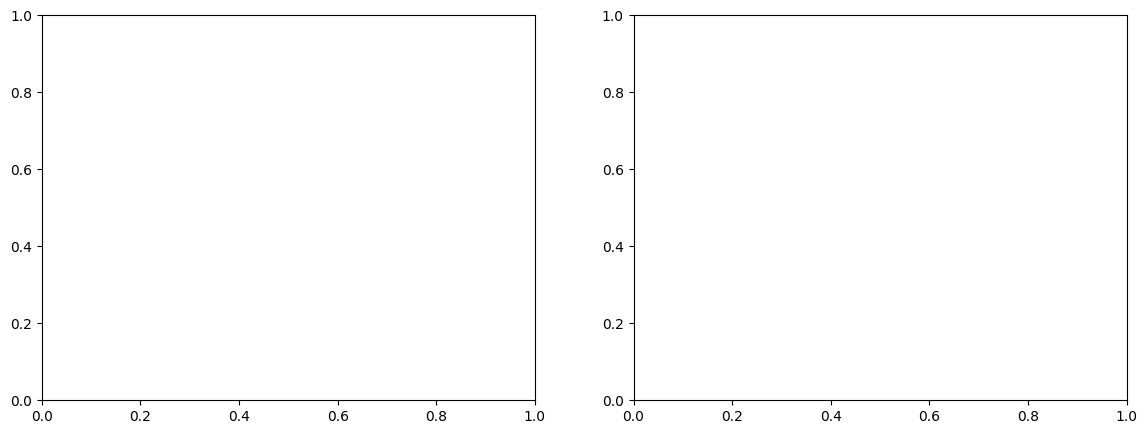

In [38]:
# PEAMINE TÖÖTLUS - OPTIMEERITUD
print("Alustame optimeeritud töötlusega...")
start_time = time.time()

episodes_list = []
curves_list = []
n_processed = 0
total_patients = df['PtID'].nunique()

# Eeltöötlus: grupeerime ja puhastame andmed
print("Ettevalmistus (duplikaatide eemaldamine)...")
patient_groups = {}
for pid, group in df.groupby("PtID"):
    patient_groups[pid] = group

print(f"\nTöötlen {total_patients} patsienti...")

for pid, group in tqdm(patient_groups.items(), desc="Patsiendid"):
    # Tuvastas episoodid
    ep = detect_episodes(group)

    if len(ep) == 0:
        n_processed += 1
        continue

    # Ekstrakti KÕIK kõverad korraga (kiirem!)
    patient_curves, valid_indices = extract_curves_batch(group, ep)

    if len(patient_curves) > 0:
        # Filtreeri episoodid, millel on kehtivad kõverad
        valid_episodes = ep.loc[valid_indices].copy()
        valid_episodes = valid_episodes.drop(columns=['start_idx'], errors='ignore')

        episodes_list.append(valid_episodes)
        curves_list.append(patient_curves)

    n_processed += 1

# Koonda tulemused
if len(episodes_list) > 0:
    episodes = pd.concat(episodes_list, ignore_index=True)
    curves = np.vstack(curves_list)
    episodes["curve_idx"] = np.arange(len(curves))
else:
    episodes = pd.DataFrame()
    curves = np.array([])

elapsed = time.time() - start_time
print(f"\n{'='*60}")
print(f"VALMIS! Aeg: {elapsed:.1f}s ({elapsed/60:.2f} min)")
print(f"Kiirus: {total_patients/elapsed:.1f} patsienti/sek")
print(f"Tuvastatud {len(episodes)} episoodi")
print(f"{'='*60}")

if len(episodes) > 0:
    print(f"\nEsimesed 5 episoodi:")
    print(episodes.head())

    # KLASTERDAMINE
    print("\nKlasterdamine...")
    scaler = StandardScaler()
    curves_scaled = scaler.fit_transform(curves)

    n_clusters = 4  # dünaamiline klastrite arv
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    episodes["cluster"] = kmeans.fit_predict(curves_scaled)

    # VISUALISEERING
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # PCA scatter
    scatter = axes[0].scatter(curves_pca[:, 0], curves_pca[:, 1],
                             c=episodes["cluster"], cmap='viridis', alpha=0.6, s=30)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0].set_title('Episoodid PCA ruumis')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0], label='Klaster')

    # Klastrite keskmised kõverad
    colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))
    for cluster_id in range(n_clusters):
        cluster_curves = curves[episodes["cluster"] == cluster_id]
        if len(cluster_curves) > 0:
            mean_curve = cluster_curves.mean(axis=0)
            std_curve = cluster_curves.std(axis=0)
            time_points = np.arange(25) * 5  # minutid

            axes[1].plot(time_points, mean_curve,
                        label=f'Klaster {cluster_id} (n={len(cluster_curves)})',
                        linewidth=2, color=colors[cluster_id])
            axes[1].fill_between(time_points,
                                mean_curve - std_curve,
                                mean_curve + std_curve,
                                alpha=0.2, color=colors[cluster_id])

    axes[1].set_xlabel('Aeg (minutid)')
    axes[1].set_ylabel('Glükoos muutus (mmol/L)')
    axes[1].set_title('Klastrite keskmised kõverad ± SD')
    axes[1].legend(loc='best', fontsize=9)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # STATISTIKA
    print(f"\n{'='*60}")
    print("KLASTRITE STATISTIKA")
    print(f"{'='*60}")
    for cluster_id in range(n_clusters):
        cluster_data = episodes[episodes["cluster"] == cluster_id]
        if len(cluster_data) > 0:
            print(f"\nKlaster {cluster_id} (n={len(cluster_data)}):")
            print(f"  Amplituud: {cluster_data['amplitude'].mean():.2f} ± {cluster_data['amplitude'].std():.2f} mmol/L")
            print(f"  Tippuaeg: {cluster_data['peak_time'].mean():.1f} ± {cluster_data['peak_time'].std():.1f} min")
            print(f"  Tõusukiirus: {cluster_data['rise_slope'].mean():.3f} ± {cluster_data['rise_slope'].std():.3f} mmol/L/min")
            print(f"  Kestus: {cluster_data['duration'].mean():.1f} ± {cluster_data['duration'].std():.1f} min")
            print(f"  Patsiendid: {cluster_data['PtID'].nunique()}")
else:
    print("\nÜhtegi episoodi ei tuvastatud!")


In [47]:
print(df[df['PtID'] == 73])


         PtID                 Period            DataDtTm  CGM  delta_min  \
7541598    73            1. Baseline 2018-01-09 12:30:00   76        NaN   
7541599    73            1. Baseline 2018-01-09 12:35:00   82   5.000000   
7541600    73            1. Baseline 2018-01-09 12:40:00   96   5.000000   
7541601    73            1. Baseline 2018-01-09 12:45:00  107   5.000000   
7541602    73            1. Baseline 2018-01-09 12:50:00  112   5.000000   
...       ...                    ...                 ...  ...        ...   
7594498    73  2. Post Randomization 2018-07-21 13:32:19  154   5.000000   
7594499    73  2. Post Randomization 2018-07-21 13:37:19  159   5.000000   
7594500    73  2. Post Randomization 2018-07-21 13:42:20  165   5.016667   
7594501    73  2. Post Randomization 2018-07-21 13:47:19  174   4.983333   
7594502    73  2. Post Randomization 2018-07-21 13:52:19  185   5.000000   

         CGM_interp   CGM_mmol  in_range  
7541598          76   4.222222      True  
7

In [39]:
import numpy as np
import pandas as pd
from tqdm import tqdm

print("KIIRE VERSIOON – Lisan 'time_above_baseline'...")

# =========================================================
# 1) TIME ABOVE BASELINE – episoodikõvera põhine
# =========================================================

def calculate_time_above_baseline_batch(df, episode_starts, window=120):
    df = df.sort_values("DataDtTm").drop_duplicates(subset=['DataDtTm'], keep='last')
    df["gl"] = df["CGM"] / 18.0
    df = df.set_index("DataDtTm").sort_index()

    results = []

    for start_time in episode_starts:
        try:
            start_time = pd.to_datetime(start_time)
            end_time = start_time + pd.Timedelta(minutes=window)

            seg = df.loc[start_time - pd.Timedelta(minutes=3):end_time + pd.Timedelta(minutes=3)]

            if len(seg) < 5:
                results.append(np.nan)
                continue

            ti = pd.date_range(start=start_time, end=end_time, freq="5min")
            curve = seg["gl"].reindex(ti).interpolate(method='linear')

            if pd.isna(curve.iloc[0]):
                curve = curve.bfill()

            baseline = curve.iloc[0] if not pd.isna(curve.iloc[0]) else 0
            curve_normalized = (curve - baseline).values

            if len(curve_normalized) != 25 or np.isnan(curve_normalized).any():
                results.append(np.nan)
                continue

            threshold = 1.0
            above_threshold = curve_normalized > threshold

            if above_threshold.any():
                last_high_idx = np.where(above_threshold)[0][-1]
                time_elevated = last_high_idx * 5
            else:
                time_elevated = 0

            results.append(time_elevated)

        except Exception:
            results.append(np.nan)

    return results



# =========================================================
# 2) Lisa time_above_baseline ja recovery_speed
# =========================================================

if 'episodes' not in locals() and 'episodes' not in globals():
    print("'episodes' DataFrame ei leitud!")
else:
    print(f"Leitud {len(episodes)} episoodi")
    print("Töötlen patsiendipõhiselt...")

    patient_groups = {pid: group for pid, group in df.groupby("PtID")}
    all_times = []

    for pid in tqdm(episodes['PtID'].unique(), desc="Patsiendid"):
        patient_episodes = episodes[episodes['PtID'] == pid]

        times = calculate_time_above_baseline_batch(
            patient_groups[pid],
            patient_episodes['start'].values
        )

        all_times.extend(times)

    episodes['time_above_baseline'] = all_times

    n_before = len(episodes)
    episodes = episodes.dropna(subset=['time_above_baseline'])
    n_after = len(episodes)

    if n_before > n_after:
        print(f"Eemaldatud {n_before - n_after} episoodi")

    episodes['recovery_speed'] = episodes['time_above_baseline'].apply(
        lambda x: 'Kiire (<60min)' if x < 60 else 'Aeglane (≥60min)'
    )


    # =========================================================
    # 3) Episoodiklasterdamine (jätad oma olemasoleva)
    # =========================================================
    # Eeldame, et episodes['cluster'] juba olemas (Klasterdamine tehtud eelnevalt)

    episode_cluster_labels = {
        0: "Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine",
        1: "Väga kõrge amplituud, väga kiire tõus, väga pikk taastumine",
        2: "Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine",
        3: "Madal amplituud, kiire tipp, lühike kestus, kiire taastumine"
    }

    if "cluster" in episodes.columns:
        episodes["episode_cluster_name"] = episodes["cluster"].map(episode_cluster_labels)
        print("Episoodide klastrinimed lisatud.")
    else:
        print("⚠ 'cluster' veergu ei leitud – episoodiklastrite nimed lisamata.")



    # =========================================================
    # 4) Episoodipõhine PREDICT funktsioon (UUENDATUD)
    # =========================================================

    def predict_episode_summary(pid, start_date=None, end_date=None):
        eps = episodes[episodes["PtID"] == pid].copy()

        if start_date is not None:
            eps = eps[eps["start"] >= pd.to_datetime(start_date)]
        if end_date is not None:
            eps = eps[eps["start"] <= pd.to_datetime(end_date)]

        if len(eps) == 0:
            return {
                "PtID": pid,
                "episode_count": 0,
                "warning": "Valitud perioodil episoode ei leitud!",
                "start_date": start_date,
                "end_date": end_date
            }

        episode_dist = (
            eps["episode_cluster_name"].value_counts().to_dict()
            if "episode_cluster_name" in eps.columns
            else {}
        )

        return {
            "PtID": pid,
            "episode_count": len(eps),
            "mean_amplitude": eps['amplitude'].mean(),
            "mean_peak_time": eps['peak_time'].mean(),
            "mean_rise_slope": eps['rise_slope'].mean(),
            "mean_duration": eps['duration'].mean(),
            "episode_cluster_distribution": episode_dist,
            "start_date": start_date,
            "end_date": end_date
        }



    # =========================================================
    # 5) Ajastuse statistika
    # =========================================================

    def compute_patient_timing_stats(pid, start_date=None, end_date=None):
        eps = episodes[episodes["PtID"] == pid].copy()

        if start_date is not None:
            eps = eps[eps["start"] >= pd.to_datetime(start_date)]
        if end_date is not None:
            eps = eps[eps["start"] <= pd.to_datetime(end_date)]

        if len(eps) == 0:
            return None

        eps['start_dt'] = pd.to_datetime(eps['start'])
        eps['date'] = eps['start_dt'].dt.date
        eps['hour'] = eps['start_dt'].dt.hour

        episodes_per_day = eps.groupby("date").size().mean()
        top_hours = eps['hour'].value_counts().head(3)

        mean_high = eps['time_above_baseline'].mean()
        median_high = eps['time_above_baseline'].median()
        pct_2h = 100 * (eps['time_above_baseline'] >= 120).mean()

        slow = (eps['recovery_speed'] == 'Aeglane (≥60min)').sum()
        fast = (eps['recovery_speed'] == 'Kiire (<60min)').sum()
        total = len(eps)

        return {
            "episodes_per_day": episodes_per_day,
            "top_hours": top_hours,
            "mean_high": mean_high,
            "median_high": median_high,
            "pct_2h": pct_2h,
            "slow": slow,
            "fast": fast,
            "total": total
        }



    # =========================================================
    # 6) Raporti väljund
    # =========================================================

    def print_patient_report(result):
        pid = result["PtID"]

        stats = compute_patient_timing_stats(
            pid,
            result["start_date"],
            result["end_date"]
        )

        print("\n🧬 EPISOODIPÕHINE RAPORT")
        print("=" * 40)

        print(f"👤 Patsient: {pid}")

        if result["start_date"] or result["end_date"]:
            print("\n📅 Periood:")
            print(f"  Alates: {result['start_date']}")
            print(f"  Kuni:   {result['end_date']}")

        print(f"\n📦 Episoodide arv: {result['episode_count']}")
        if result["episode_count"] == 0:
            print("Episoode ei leitud.")
            return

        print("\n📈 Episoodide keskmised väärtused:")
        print(f"  • Amplituud: {result['mean_amplitude']:.2f} mmol/L")
        print(f"  • Tippuaeg: {result['mean_peak_time']:.1f} min")
        print(f"  • Tõusukiirus: {result['mean_rise_slope']:.3f} mmol/L/min")
        print(f"  • Kestus: {result['mean_duration']:.1f} min")

        print("\n🍽️ Episoodide jaotus klastrite vahel:")
        for name, count in result['episode_cluster_distribution'].items():
            pct = 100 * count / result['episode_count']
            print(f"  • {name}: {count} episoodi ({pct:.1f}%)")

        print("=" * 40)

        if stats is not None:
            print("\n⏰ AJASTUSE ANALÜÜS:")
            print(f"  • Episoode päevas: {stats['episodes_per_day']:.2f}")
            print(f"  • Sagedasemad tunnid:")
            for hour, count in stats["top_hours"].items():
                print(f"     - {hour:02d}:00 → {count} episoodi")

            print("\n📊 GLÜKOOSI PÜSIMINE KÕRGEL:")
            print(f"  • Keskmine: {stats['mean_high']:.1f} min")
            print(f"  • Mediaan: {stats['median_high']:.1f} min")
            print(f"  • ≥2h episoodid: {stats['pct_2h']:.1f}%")

            print("\n⚡ Taastumiskiirus:")
            print(f"     - Aeglane (≥60min): {stats['slow']} episoodi")
            print(f"     - Kiire (<60min): {stats['fast']} episoodi")

            print("=" * 40)



    print("\nNüüd saad kasutada:")
    print("   r = predict_episode_summary(PATIENT_ID, start_date, end_date)")
    print("   print_patient_report(r)")


KIIRE VERSIOON – Lisan 'time_above_baseline'...
Leitud 71405 episoodi
Töötlen patsiendipõhiselt...


Patsiendid: 100%|██████████| 168/168 [01:57<00:00,  1.43it/s]

Episoodide klastrinimed lisatud.

Nüüd saad kasutada:
   r = predict_episode_summary(PATIENT_ID, start_date, end_date)
   print_patient_report(r)


In [40]:
 r = predict_episode_summary(2, '2018-01-10', '2018-01-23')
 print_patient_report(r)


🧬 EPISOODIPÕHINE RAPORT
👤 Patsient: 2

📅 Periood:
  Alates: 2018-01-10
  Kuni:   2018-01-23

📦 Episoodide arv: 18

📈 Episoodide keskmised väärtused:
  • Amplituud: 3.26 mmol/L
  • Tippuaeg: 60.0 min
  • Tõusukiirus: 0.056 mmol/L/min
  • Kestus: 66.4 min

🍽️ Episoodide jaotus klastrite vahel:
  • Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine: 7 episoodi (38.9%)
  • Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine: 5 episoodi (27.8%)
  • Madal amplituud, kiire tipp, lühike kestus, kiire taastumine: 4 episoodi (22.2%)
  • Väga kõrge amplituud, väga kiire tõus, väga pikk taastumine: 2 episoodi (11.1%)

⏰ AJASTUSE ANALÜÜS:
  • Episoode päevas: 1.80
  • Sagedasemad tunnid:
     - 21:00 → 3 episoodi
     - 17:00 → 2 episoodi
     - 12:00 → 2 episoodi

📊 GLÜKOOSI PÜSIMINE KÕRGEL:
  • Keskmine: 100.8 min
  • Mediaan: 120.0 min
  • ≥2h episoodid: 66.7%

⚡ Taastumiskiirus:
     - Aeglane (≥60min): 16 episoodi
     - Kiire (<60min): 2 episoodi


In [41]:
 r = predict_episode_summary(3, '2018-01-10', '2018-01-23')
 print_patient_report(r)


🧬 EPISOODIPÕHINE RAPORT
👤 Patsient: 3

📅 Periood:
  Alates: 2018-01-10
  Kuni:   2018-01-23

📦 Episoodide arv: 22

📈 Episoodide keskmised väärtused:
  • Amplituud: 4.24 mmol/L
  • Tippuaeg: 58.4 min
  • Tõusukiirus: 0.073 mmol/L/min
  • Kestus: 64.5 min

🍽️ Episoodide jaotus klastrite vahel:
  • Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine: 8 episoodi (36.4%)
  • Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine: 7 episoodi (31.8%)
  • Väga kõrge amplituud, väga kiire tõus, väga pikk taastumine: 6 episoodi (27.3%)
  • Madal amplituud, kiire tipp, lühike kestus, kiire taastumine: 1 episoodi (4.5%)

⏰ AJASTUSE ANALÜÜS:
  • Episoode päevas: 2.00
  • Sagedasemad tunnid:
     - 22:00 → 4 episoodi
     - 14:00 → 3 episoodi
     - 13:00 → 3 episoodi

📊 GLÜKOOSI PÜSIMINE KÕRGEL:
  • Keskmine: 109.1 min
  • Mediaan: 120.0 min
  • ≥2h episoodid: 59.1%

⚡ Taastumiskiirus:
     - Aeglane (≥60min): 22 episoodi
     - Kiire (<60min): 0 episoodi


In [46]:
 r = predict_episode_summary(14, '2018-07-08', '2018-07-22')
 print_patient_report(r)


🧬 EPISOODIPÕHINE RAPORT
👤 Patsient: 14

📅 Periood:
  Alates: 2018-07-08
  Kuni:   2018-07-22

📦 Episoodide arv: 18

📈 Episoodide keskmised väärtused:
  • Amplituud: 2.77 mmol/L
  • Tippuaeg: 53.1 min
  • Tõusukiirus: 0.058 mmol/L/min
  • Kestus: 59.7 min

🍽️ Episoodide jaotus klastrite vahel:
  • Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine: 7 episoodi (38.9%)
  • Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine: 7 episoodi (38.9%)
  • Madal amplituud, kiire tipp, lühike kestus, kiire taastumine: 4 episoodi (22.2%)

⏰ AJASTUSE ANALÜÜS:
  • Episoode päevas: 1.80
  • Sagedasemad tunnid:
     - 14:00 → 4 episoodi
     - 18:00 → 2 episoodi
     - 10:00 → 2 episoodi

📊 GLÜKOOSI PÜSIMINE KÕRGEL:
  • Keskmine: 104.4 min
  • Mediaan: 120.0 min
  • ≥2h episoodid: 66.7%

⚡ Taastumiskiirus:
     - Aeglane (≥60min): 17 episoodi
     - Kiire (<60min): 1 episoodi


In [48]:
 r = predict_episode_summary(73, '2018-01-09', '2018-01-23')
 print_patient_report(r)


🧬 EPISOODIPÕHINE RAPORT
👤 Patsient: 73

📅 Periood:
  Alates: 2018-01-09
  Kuni:   2018-01-23

📦 Episoodide arv: 38

📈 Episoodide keskmised väärtused:
  • Amplituud: 4.47 mmol/L
  • Tippuaeg: 63.3 min
  • Tõusukiirus: 0.071 mmol/L/min
  • Kestus: 71.2 min

🍽️ Episoodide jaotus klastrite vahel:
  • Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine: 16 episoodi (42.1%)
  • Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine: 10 episoodi (26.3%)
  • Väga kõrge amplituud, väga kiire tõus, väga pikk taastumine: 7 episoodi (18.4%)
  • Madal amplituud, kiire tipp, lühike kestus, kiire taastumine: 5 episoodi (13.2%)

⏰ AJASTUSE ANALÜÜS:
  • Episoode päevas: 2.92
  • Sagedasemad tunnid:
     - 09:00 → 4 episoodi
     - 18:00 → 4 episoodi
     - 10:00 → 3 episoodi

📊 GLÜKOOSI PÜSIMINE KÕRGEL:
  • Keskmine: 102.4 min
  • Mediaan: 120.0 min
  • ≥2h episoodid: 65.8%

⚡ Taastumiskiirus:
     - Aeglane (≥60min): 34 episoodi
     - Kiire (<60min): 4 episoodi


# Lisame patsiendipõhise klasterdamise lisaks episoodi põhisele

Leiame patsiendipõhisele optimaalse klastrite arvu

In [ ]:
def find_optimal_clusters(patient_profiles, max_clusters=10, plot=True):
    """
    Leiab optimaalse klastrite arvu mitme mõõdiku abil

    Args:
        patient_profiles: DataFrame kõigi patsientide profiilidega
        max_clusters: Maksimaalne klastrite arv testimiseks
        plot: Kas joonistada graafikud

    Returns:
        dict: Mõõdikud iga klastrite arvu kohta
    """
    # Standardiseeri andmed
    scaler = StandardScaler()
    profiles_scaled = scaler.fit_transform(
        patient_profiles.drop('PtID', axis=1, errors='ignore')
    )

    results = {
        'n_clusters': [],
        'silhouette': [],
        'davies_bouldin': [],
        'calinski_harabasz': [],
        'inertia': []
    }

    print("=" * 70)
    print("KLASTRITE ARVU OPTIMEERIMINE")
    print("=" * 70)
    print("\nTestime 2 kuni {} klastrit...\n".format(max_clusters))

    # Testi erinevaid klastrite arve
    for n in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)
        labels = kmeans.fit_predict(profiles_scaled)

        # Arvuta mõõdikud
        sil = silhouette_score(profiles_scaled, labels)
        db = davies_bouldin_score(profiles_scaled, labels)
        ch = calinski_harabasz_score(profiles_scaled, labels)
        inertia = kmeans.inertia_

        results['n_clusters'].append(n)
        results['silhouette'].append(sil)
        results['davies_bouldin'].append(db)
        results['calinski_harabasz'].append(ch)
        results['inertia'].append(inertia)

        print(f"n={n}: Silhouette={sil:.3f}, Davies-Bouldin={db:.3f}, "
              f"Calinski-Harabasz={ch:.1f}")

    # Leia parimad väärtused
    best_sil_idx = np.argmax(results['silhouette'])
    best_db_idx = np.argmin(results['davies_bouldin'])
    best_ch_idx = np.argmax(results['calinski_harabasz'])

    print("\n" + "=" * 70)
    print("SOOVITUSED:")
    print("=" * 70)
    print(f"🏆 Parim Silhouette skoor: n={results['n_clusters'][best_sil_idx]} "
          f"(skoor={results['silhouette'][best_sil_idx]:.3f})")
    print(f"   → Kõrgem on parem (vahemik -1 kuni 1)")
    print(f"   → >0.5 = hea, >0.7 = suurepärane eraldatus\n")

    print(f"🏆 Parim Davies-Bouldin indeks: n={results['n_clusters'][best_db_idx]} "
          f"(skoor={results['davies_bouldin'][best_db_idx]:.3f})")
    print(f"   → Madalam on parem (vahemik 0 kuni ∞)")
    print(f"   → <1 = hea eraldatus\n")

    print(f"🏆 Parim Calinski-Harabasz indeks: n={results['n_clusters'][best_ch_idx]} "
          f"(skoor={results['calinski_harabasz'][best_ch_idx]:.1f})")
    print(f"   → Kõrgem on parem")
    print(f"   → Suurem väärtus = paremini eraldatud ja tihedamad klastrid\n")

    # Elbow meetod
    inertias = np.array(results['inertia'])
    diffs = np.diff(inertias)
    elbow_idx = np.argmax(np.abs(np.diff(diffs))) + 2  # +2 sest diff vähendab pikkust 2x
    if elbow_idx < len(results['n_clusters']):
        print(f"📐 Elbow meetod soovitab: n={results['n_clusters'][elbow_idx]}")
        print(f"   → Punkt, kus 'küünarnukk' on kõveras\n")

    print("=" * 70)
    print("💡 JÄRELDUS:")

    # Hääletus
    votes = [
        results['n_clusters'][best_sil_idx],
        results['n_clusters'][best_db_idx],
        results['n_clusters'][best_ch_idx]
    ]

    from collections import Counter
    vote_counts = Counter(votes)
    recommended = vote_counts.most_common(1)[0][0]

    print(f"   Enamik mõõdikuid soovitab: n={recommended} klastrit")

    # Kui ei ole selget võitjat
    if len(set(votes)) == len(votes):
        print(f"   ⚠️ Mõõdikud ei ole ühel meelel!")
        print(f"   Kaaluge n={results['n_clusters'][best_sil_idx]} (silhouette) või")
        print(f"           n={results['n_clusters'][best_db_idx]} (davies-bouldin)")

    print("=" * 70)

    # Joonista graafikud
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Klastrite arvu optimeerimine', fontsize=16, fontweight='bold')

        # Silhouette
        axes[0, 0].plot(results['n_clusters'], results['silhouette'], 'o-', linewidth=2, markersize=8)
        axes[0, 0].axvline(results['n_clusters'][best_sil_idx], color='red', linestyle='--', alpha=0.7, label='Optimum')
        axes[0, 0].set_xlabel('Klastrite arv')
        axes[0, 0].set_ylabel('Silhouette skoor')
        axes[0, 0].set_title('Silhouette skoor (kõrgem = parem)')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].legend()

        # Davies-Bouldin
        axes[0, 1].plot(results['n_clusters'], results['davies_bouldin'], 'o-', linewidth=2, markersize=8, color='orange')
        axes[0, 1].axvline(results['n_clusters'][best_db_idx], color='red', linestyle='--', alpha=0.7, label='Optimum')
        axes[0, 1].set_xlabel('Klastrite arv')
        axes[0, 1].set_ylabel('Davies-Bouldin indeks')
        axes[0, 1].set_title('Davies-Bouldin indeks (madalam = parem)')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].legend()

        # Calinski-Harabasz
        axes[1, 0].plot(results['n_clusters'], results['calinski_harabasz'], 'o-', linewidth=2, markersize=8, color='green')
        axes[1, 0].axvline(results['n_clusters'][best_ch_idx], color='red', linestyle='--', alpha=0.7, label='Optimum')
        axes[1, 0].set_xlabel('Klastrite arv')
        axes[1, 0].set_ylabel('Calinski-Harabasz indeks')
        axes[1, 0].set_title('Calinski-Harabasz indeks (kõrgem = parem)')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].legend()

        # Elbow (Inertia)
        axes[1, 1].plot(results['n_clusters'], results['inertia'], 'o-', linewidth=2, markersize=8, color='purple')
        if elbow_idx < len(results['n_clusters']):
            axes[1, 1].axvline(results['n_clusters'][elbow_idx], color='red', linestyle='--', alpha=0.7, label='Elbow')
        axes[1, 1].set_xlabel('Klastrite arv')
        axes[1, 1].set_ylabel('Inertia (WCSS)')
        axes[1, 1].set_title('Elbow meetod (otsime küünarnukka)')
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend()

        plt.tight_layout()
        plt.show()

    return pd.DataFrame(results)



KLASTRITE ARVU OPTIMEERIMINE

Testime 2 kuni 8 klastrit...

n=2: Silhouette=0.382, Davies-Bouldin=0.974, Calinski-Harabasz=134.2
n=3: Silhouette=0.349, Davies-Bouldin=1.011, Calinski-Harabasz=115.6
n=4: Silhouette=0.339, Davies-Bouldin=0.922, Calinski-Harabasz=117.9
n=5: Silhouette=0.333, Davies-Bouldin=0.929, Calinski-Harabasz=117.3
n=6: Silhouette=0.341, Davies-Bouldin=0.867, Calinski-Harabasz=117.6
n=7: Silhouette=0.340, Davies-Bouldin=0.871, Calinski-Harabasz=121.2
n=8: Silhouette=0.340, Davies-Bouldin=0.841, Calinski-Harabasz=119.1

SOOVITUSED:
🏆 Parim Silhouette skoor: n=2 (skoor=0.382)
   → Kõrgem on parem (vahemik -1 kuni 1)
   → >0.5 = hea, >0.7 = suurepärane eraldatus

🏆 Parim Davies-Bouldin indeks: n=8 (skoor=0.841)
   → Madalam on parem (vahemik 0 kuni ∞)
   → <1 = hea eraldatus

🏆 Parim Calinski-Harabasz indeks: n=2 (skoor=134.2)
   → Kõrgem on parem
   → Suurem väärtus = paremini eraldatud ja tihedamad klastrid

📐 Elbow meetod soovitab: n=5
   → Punkt, kus 'küünarnukk' on

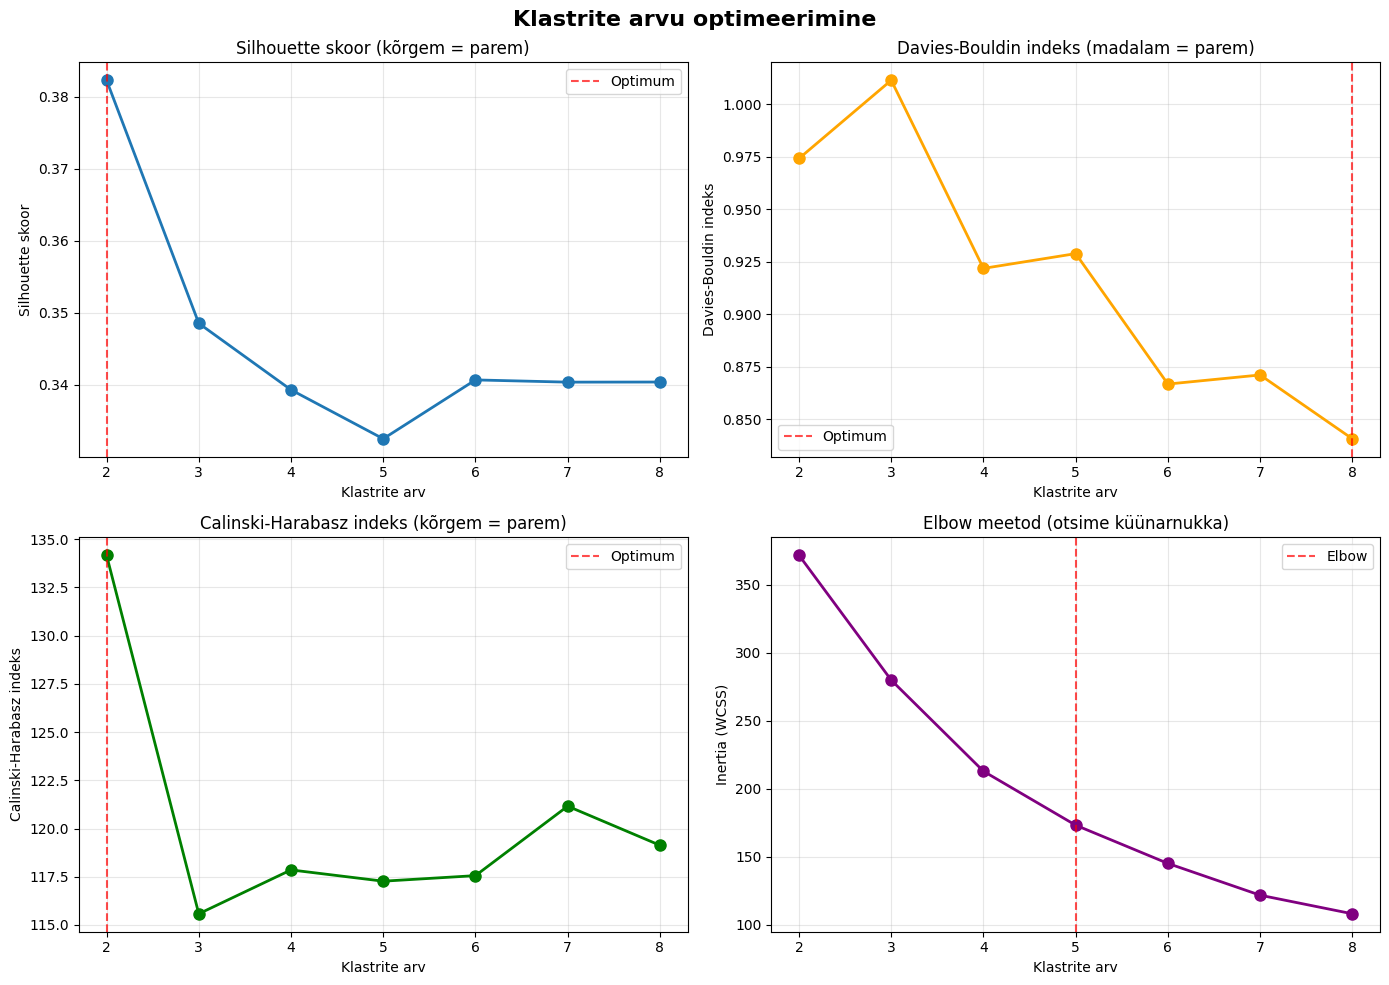


ÜKSIKASJALIK TABEL:
 n_clusters  silhouette  davies_bouldin  calinski_harabasz    inertia
          2    0.382278        0.974103         134.166793 371.633381
          3    0.348538        1.011337         115.577912 279.889865
          4    0.339309        0.921788         117.853078 212.937946
          5    0.332513        0.928813         117.268375 173.296302
          6    0.340686        0.866719         117.556859 145.193758
          7    0.340378        0.871052         121.158010 121.844964
          8    0.340393        0.840665         119.131074 108.177991


Treenime mudeli 2 klastriga...
✓ Mudel treenitud 2 klastriga!


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# KASUTAMINE:

# 1. Loo patsiendi profiilid (nagu sul juba on)
patient_profiles = episodes.groupby('PtID').agg({
    'amplitude': 'mean',
    'peak_time': 'mean',
    'rise_slope': 'mean',
    'duration': 'mean'
}).reset_index()

# 2. Leia optimaalne klastrite arv
results_df = find_optimal_clusters(patient_profiles, max_clusters=8, plot=True)

# 3. Vaata tulemusi tabelina
print("\nÜKSIKASJALIK TABEL:")
print(results_df.to_string(index=False))

# 4. Nüüd treenime mudelid parima klastrite arvuga
# Näiteks kui parim on 4:
optimal_n = results_df.loc[results_df['silhouette'].idxmax(), 'n_clusters']
print(f"\n\nTreenime mudeli {optimal_n} klastriga...")

scaler = StandardScaler()
profiles_scaled = scaler.fit_transform(patient_profiles.drop('PtID', axis=1))

kmeans_optimal = KMeans(n_clusters=int(optimal_n), random_state=42, n_init=10)
patient_profiles['patient_cluster'] = kmeans_optimal.fit_predict(profiles_scaled)

print(f"✓ Mudel treenitud {optimal_n} klastriga!")

Episoodidele nimede panekuks vaatame nende keskmised

In [ ]:
episodes.groupby("cluster")[['amplitude','peak_time','rise_slope','duration','time_above_baseline']].mean()


,amplitude,peak_time,rise_slope,duration,time_above_baseline
cluster,,,,,
0,2.643956,59.766851,0.046962,66.771729,81.450061
1,7.494457,63.210078,0.123598,70.596014,119.634620
2,4.149482,58.885493,0.074678,65.934268,117.058614
3,2.501179,39.225504,0.067563,45.546157,62.219832


Episoodide klastrid
* 0: "Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine",
* 1: "Väga kõrge amplituud, väga kiire tõus, väga pikk taastumine",
* 2: "Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine",
* 3: "Madal amplituud, kiire tipp, lühike kestus, kiire taastumine"


Patsientide klastritele nimede panekuks vaatame klastrite keskmisi

In [ ]:
patient_centroids = pd.DataFrame(
    kmeans_patients.cluster_centers_,
    columns=['amplitude', 'peak_time', 'rise_slope', 'duration']
)

print(patient_centroids)

   amplitude  peak_time  rise_slope  duration
0  -0.525235   0.692297   -0.639969  0.678714
1   0.577759  -0.761527    0.703966 -0.746585


* 0: "Aeglase tõusuga, madala amplituudiga ja pika episoodiga profiil"
* 1: "Kiire kõrge amplituudiga profiil"

Klasterdame ja teeme kasutatavaks patsienti sisestades

Vana

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

print("KIIRE VERSIOON - Lisan 'time_above_baseline'...")

def calculate_time_above_baseline_batch(df, episode_starts, window=120):
    """
    Mõõdab kui kaua glükoos püsib kõrgel pärast söömist ühe patsiendi kohta.
    """
    df = df.sort_values("DataDtTm").drop_duplicates(subset=['DataDtTm'], keep='last')
    df["gl"] = df["CGM"] / 18.0
    df = df.set_index("DataDtTm").sort_index()

    results = []

    for start_time in episode_starts:
        try:
            start_time = pd.to_datetime(start_time)
            end_time = start_time + pd.Timedelta(minutes=window)

            seg = df.loc[start_time - pd.Timedelta(minutes=3):end_time + pd.Timedelta(minutes=3)]

            if len(seg) < 5:
                results.append(np.nan)
                continue

            ti = pd.date_range(start=start_time, end=end_time, freq="5min")
            curve = seg["gl"].reindex(ti).interpolate(method='linear')

            if pd.isna(curve.iloc[0]):
                curve = curve.bfill()

            baseline = curve.iloc[0] if not pd.isna(curve.iloc[0]) else 0
            curve_normalized = (curve - baseline).values

            if len(curve_normalized) != 25 or np.isnan(curve_normalized).any():
                results.append(np.nan)
                continue

            # Aeg >1 mmol/L
            threshold = 1.0
            above_threshold = curve_normalized > threshold

            if above_threshold.any():
                last_high_idx = np.where(above_threshold)[0][-1]
                time_elevated = last_high_idx * 5  # minutid
            else:
                time_elevated = 0

            results.append(time_elevated)

        except Exception:
            results.append(np.nan)

    return results


# -------------------------------------------------------
# 1) KONTROLLI, ET EPISODES ON OLEMAS
# -------------------------------------------------------

if 'episodes' not in locals() and 'episodes' not in globals():
    print("'episodes' DataFrame ei leitud!")
else:
    print(f"Leitud {len(episodes)} episoodi")
    print("Töötlen patsiendipõhiselt...")

    # -------------------------------------------------------
    # 2) ARVUTA time_above_baseline
    # -------------------------------------------------------

    patient_groups = {pid: group for pid, group in df.groupby("PtID")}

    all_times = []

    for pid in tqdm(episodes['PtID'].unique(), desc="Patsiendid"):
        patient_episodes = episodes[episodes['PtID'] == pid]

        times = calculate_time_above_baseline_batch(
            patient_groups[pid],
            patient_episodes['start'].values
        )

        all_times.extend(times)

    episodes['time_above_baseline'] = all_times

    # Remove NaN
    n_before = len(episodes)
    episodes = episodes.dropna(subset=['time_above_baseline'])
    n_after = len(episodes)

    if n_before > n_after:
        print(f"Eemaldatud {n_before - n_after} episoodi, kus ei saanud arvutada")

    episodes['recovery_speed'] = episodes['time_above_baseline'].apply(
        lambda x: 'Kiire (<60min)' if x < 60 else 'Aeglane (≥60min)'
    )

    print("\n=== STATISTIKA ===")
    print(f"Keskmine: {episodes['time_above_baseline'].mean():.1f} min")
    print(f"Mediaan: {episodes['time_above_baseline'].median():.1f} min")
    print(f">2h: {(episodes['time_above_baseline'] >= 120).sum()} episoodi\n")


    # -------------------------------------------------------
    # 3) Uuenda patient_profiles + klasterda
    # -------------------------------------------------------

    print("Uuendan patient_profiles...")

    patient_profiles = episodes.groupby('PtID').agg({
        'amplitude': 'mean',
        'peak_time': 'mean',
        'rise_slope': 'mean',
        'duration': 'mean'
    }).reset_index()

    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans

    scaler = StandardScaler()
    profiles_scaled = scaler.fit_transform(patient_profiles.drop('PtID', axis=1))

    kmeans_patients = KMeans(n_clusters=2, random_state=42, n_init=10)
    patient_profiles['patient_cluster'] = kmeans_patients.fit_predict(profiles_scaled)

    episodes = episodes.drop(columns=['patient_cluster'], errors='ignore')
    episodes = episodes.merge(
        patient_profiles[['PtID', 'patient_cluster']],
        on='PtID',
        how='left'
    )

    print("Patsiendi klaster lisatud.")

    # -------------------------------------------------------
    # 4) LISA INIMLOETAVAD NIMED (PATS + EPIS)
    # -------------------------------------------------------

    print("Lisa klastritele nimed...")

    patient_cluster_labels = {
        0: "Aeglane madala amplituudiga profiil",
        1: "Kiire kõrge amplituudiga profiil",
    }

    episode_cluster_labels = {
        0: "Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine",
        1: "Väga kõrge amplituud, väga kiire tõus, väga pikk taastumine",
        2: "Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine",
        3: "Madal amplituud, kiire tipp, lühike kestus, kiire taastumine"
    }

    # Add patient cluster names
    episodes["patient_cluster_name"] = episodes["patient_cluster"].map(patient_cluster_labels)

    if "cluster" in episodes.columns:
        episodes["episode_cluster_name"] = episodes["cluster"].map(episode_cluster_labels)
        print("Episoodide klastrinimed lisatud (kasutati episodes['cluster']).")
    else:
        print("⚠ Episoodide klastriveergu 'cluster' ei leitud!")

    # -------------------------------------------------------
    # 5) PREDICT_PATIENT_CLUSTER FUNKTSIOON (UUENDATUD)
    # -------------------------------------------------------

    def predict_patient_cluster(pid, start_date=None, end_date=None):
        if pid not in patient_profiles['PtID'].values:
            return f"Patsienti {pid} ei leitud."

        row = patient_profiles.loc[patient_profiles['PtID'] == pid].iloc[0]

        cluster_num = row['patient_cluster']
        cluster_name = patient_cluster_labels.get(cluster_num, "Tundmatu klaster")

        # Episoodide statistika
        eps = episodes[episodes['PtID'] == pid].copy()

        # Kui ajaperiood on määratud → filtreeri
        if start_date is not None:
            eps = eps[eps['start'] >= pd.to_datetime(start_date)]

        if end_date is not None:
            eps = eps[eps['start'] <= pd.to_datetime(end_date)]

        if len(eps) == 0:
          return {
              "PtID": pid,
              "cluster_num": cluster_num,
              "cluster_name": cluster_name,
              "episode_count": 0,
              "warning": "Valitud perioodil episoode ei leitud!",
          }

        episode_dist = (
            eps['episode_cluster_name'].value_counts().to_dict()
            if "episode_cluster_name" in eps.columns
            else {}
        )

        return {
            "PtID": pid,
            "cluster_num": int(cluster_num),
            "cluster_name": cluster_name,
            "episode_count": len(eps),
            "mean_amplitude": eps['amplitude'].mean(),
            "mean_peak_time": eps['peak_time'].mean(),
            "mean_rise_slope": eps['rise_slope'].mean(),
            "mean_duration": eps['duration'].mean(),
            "episode_cluster_distribution": episode_dist,
            "start_date": start_date,
            "end_date": end_date

        }

    # -------------------------------------------------------
    # 6) ILUS INIMLOETAV VÄLJUND
    # -------------------------------------------------------

    def print_patient_report(result):
        pid = result["PtID"]
        if result["start_date"] or result["end_date"]:
          print("\n📅 Periood:")
          print(f"  Alates: {result['start_date']}")
          print(f"  Kuni:   {result['end_date']}")
        print("\n🧬 PATSIENDI PROFILI RAPORT")
        print("="*40)
        print(f"👤 Patsient: {result['PtID']}")
        if start_date or end_date:
          print("\n📅 Periood:")
          print(f"  Alates: {start_date}")
          print(f"  Kuni:   {end_date}")
        print(f"📦 Episoodide arv: {result['episode_count']}")

        print("\n📈 Keskväärtused:")
        print(f"  • Amplituud: {result['mean_amplitude']:.2f} mmol/L")
        print(f"  • Tippuaeg: {result['mean_peak_time']:.1f} min")
        print(f"  • Tõusukiirus: {result['mean_rise_slope']:.3f} mmol/L/min")
        print(f"  • Kestus: {result['mean_duration']:.1f} min")

        print("\n🍽️ Episoodide jaotus klastrite vahel:")
        for name, count in result['episode_cluster_distribution'].items():
            pct = 100 * count / result['episode_count']
            print(f"  • {name}: {count} episoodi ({pct:.1f}%)")

        print("="*40)

        if stats is not None:
          print("\n⏰ AJASTUSE ANALÜÜS:")

          print(f"  • Episoode päevas (keskm.): {stats['episodes_per_day']:.2f}")
          print("  • Kõige sagedasemad tunnid:")
          for hour, count in stats["top_hours"].items():
              print(f"     - Kell {hour:02d}:00: {count} episoodi")

          print("\n📊 GLÜKOOSI PÜSIVUS KÕRGEL:")
          print(f"  • Keskmine aeg kõrgel: {stats['mean_high']:.1f} min")
          print(f"  • Mediaan: {stats['median_high']:.1f} min")
          print(f"  • Pikaajaline kõrgus (≥2h): {stats['pct_2h']:.1f}%")

          print("  • Taastumiskiirus:")
          print(f"     - Aeglane (≥60min): {stats['slow']} episoodi ({100*stats['slow']/stats['total']:.1f}%)")
          print(f"     - Kiire (<60min): {stats['fast']} episoodi ({100*stats['fast']/stats['total']:.1f}%)")

          print("="*40)


    print("\nNüüd saad kasutada:")
    print("   r = predict_patient_cluster(PATIENT_ID)")
    print("   print_patient_report(r)")


KIIRE VERSIOON - Lisan 'time_above_baseline'...
Leitud 71405 episoodi
Töötlen patsiendipõhiselt...


Patsiendid: 100%|██████████| 168/168 [01:11<00:00,  2.35it/s]


=== STATISTIKA ===
Keskmine: 94.9 min
Mediaan: 120.0 min
>2h: 40737 episoodi

Uuendan patient_profiles...
Patsiendi klaster lisatud.
Lisa klastritele nimed...
Episoodide klastrinimed lisatud (kasutati episodes['cluster']).

Nüüd saad kasutada:
   predict_patient_cluster(PATIENT_ID)

Nüüd saad kasutada:
   r = predict_patient_cluster(PATIENT_ID)
   print_patient_report(r)


In [ ]:
# Vali üks patsient
patient_id = 1

# Analüüsi teda
result = predict_patient_cluster(patient_id)
print_patient_report(result)


🧬 PATSIENDI PROFILI RAPORT
👤 Patsient: 1
📌 Patsiendi klaster: Kiire kõrge amplituudiga profiil (#1)
📦 Episoodide arv: 336

📈 Keskväärtused:
  • Amplituud: 3.32 mmol/L
  • Tippuaeg: 53.2 min
  • Tõusukiirus: 0.064 mmol/L/min
  • Kestus: 60.4 min

🍽️ Episoodide jaotus klastrite vahel:
  • Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine: 119 episoodi (35.4%)
  • Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine: 116 episoodi (34.5%)
  • Madal amplituud, kiire tipp, lühike kestus, kiire taastumine: 74 episoodi (22.0%)
  • Väga kõrge amplituud, väga kiire tõus, väga pikk taastumine: 27 episoodi (8.0%)

⏰ AJASTUSE ANALÜÜS:
  • Episoode päevas (keskm.): 4.11
  • Kõige sagedasemad tunnid:
     - Kell 14:00: 51 episoodi
     - Kell 13:00: 49 episoodi
     - Kell 12:00: 46 episoodi

📊 GLÜKOOSI PÜSIVUS KÕRGEL:
  • Keskmine aeg kõrgel: 96.4 min
  • Mediaan: 120.0 min
  • Pikaajaline kõrgus (≥2h): 58.8%
  • Taastumiskiirus:
     - Aeglane (≥60min): 696 episoodi (85.5%)
     - Kiire 

In [ ]:
# Vali üks patsient
patient_id = 3

# Analüüsi teda
result = predict_patient_cluster(patient_id)
print_patient_report(result)


🧬 PATSIENDI PROFILI RAPORT
👤 Patsient: 3
📌 Patsiendi klaster: Kiire kõrge amplituudiga profiil (#1)
📦 Episoodide arv: 486

📈 Keskväärtused:
  • Amplituud: 3.63 mmol/L
  • Tippuaeg: 56.6 min
  • Tõusukiirus: 0.067 mmol/L/min
  • Kestus: 63.5 min

🍽️ Episoodide jaotus klastrite vahel:
  • Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine: 181 episoodi (37.2%)
  • Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine: 177 episoodi (36.4%)
  • Väga kõrge amplituud, väga kiire tõus, väga pikk taastumine: 66 episoodi (13.6%)
  • Madal amplituud, kiire tipp, lühike kestus, kiire taastumine: 62 episoodi (12.8%)

⏰ AJASTUSE ANALÜÜS:
  • Episoode päevas (keskm.): 4.11
  • Kõige sagedasemad tunnid:
     - Kell 14:00: 51 episoodi
     - Kell 13:00: 49 episoodi
     - Kell 12:00: 46 episoodi

📊 GLÜKOOSI PÜSIVUS KÕRGEL:
  • Keskmine aeg kõrgel: 96.4 min
  • Mediaan: 120.0 min
  • Pikaajaline kõrgus (≥2h): 58.8%
  • Taastumiskiirus:
     - Aeglane (≥60min): 696 episoodi (85.5%)
     - Kiire

In [ ]:
# Vali üks patsient
patient_id = 14

# Analüüsi teda
result = predict_patient_cluster(patient_id)
print_patient_report(result)


🧬 PATSIENDI PROFILI RAPORT
👤 Patsient: 14
📌 Patsiendi klaster: Aeglane madala amplituudiga profiil (#0)
📦 Episoodide arv: 461

📈 Keskväärtused:
  • Amplituud: 3.22 mmol/L
  • Tippuaeg: 60.1 min
  • Tõusukiirus: 0.056 mmol/L/min
  • Kestus: 66.6 min

🍽️ Episoodide jaotus klastrite vahel:
  • Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine: 235 episoodi (51.0%)
  • Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine: 144 episoodi (31.2%)
  • Madal amplituud, kiire tipp, lühike kestus, kiire taastumine: 56 episoodi (12.1%)
  • Väga kõrge amplituud, väga kiire tõus, väga pikk taastumine: 26 episoodi (5.6%)

⏰ AJASTUSE ANALÜÜS:
  • Episoode päevas (keskm.): 4.11
  • Kõige sagedasemad tunnid:
     - Kell 14:00: 51 episoodi
     - Kell 13:00: 49 episoodi
     - Kell 12:00: 46 episoodi

📊 GLÜKOOSI PÜSIVUS KÕRGEL:
  • Keskmine aeg kõrgel: 96.4 min
  • Mediaan: 120.0 min
  • Pikaajaline kõrgus (≥2h): 58.8%
  • Taastumiskiirus:
     - Aeglane (≥60min): 696 episoodi (85.5%)
     - Ki

Merilini mõte:
- palju söögiepisoode päevas

- jooksuta uuesti episoodide keskmised klastri kõverad


In [ ]:
# Vali üks patsient
patient_id = 73

# Analüüsi teda
result = predict_patient_cluster(patient_id)
print_patient_report(result)


🧬 PATSIENDI PROFILI RAPORT
👤 Patsient: 73
📌 Patsiendi klaster: Kiire kõrge amplituudiga profiil (#1)
📦 Episoodide arv: 419

📈 Keskväärtused:
  • Amplituud: 4.13 mmol/L
  • Tippuaeg: 56.6 min
  • Tõusukiirus: 0.075 mmol/L/min
  • Kestus: 63.4 min

🍽️ Episoodide jaotus klastrite vahel:
  • Kõrge amplituud, keskmise kiirusega tõus, pikk taastumine: 148 episoodi (35.3%)
  • Mõõdukas amplituud, pikk tõusuaeg, keskmine taastumine: 143 episoodi (34.1%)
  • Väga kõrge amplituud, väga kiire tõus, väga pikk taastumine: 72 episoodi (17.2%)
  • Madal amplituud, kiire tipp, lühike kestus, kiire taastumine: 56 episoodi (13.4%)

⏰ AJASTUSE ANALÜÜS:
  • Episoode päevas (keskm.): 4.11
  • Kõige sagedasemad tunnid:
     - Kell 14:00: 51 episoodi
     - Kell 13:00: 49 episoodi
     - Kell 12:00: 46 episoodi

📊 GLÜKOOSI PÜSIVUS KÕRGEL:
  • Keskmine aeg kõrgel: 96.4 min
  • Mediaan: 120.0 min
  • Pikaajaline kõrgus (≥2h): 58.8%
  • Taastumiskiirus:
     - Aeglane (≥60min): 696 episoodi (85.5%)
     - Kiir

Merette to do:
- ajastuse analüüs kõigil patsiendiel sama
- glükoosi püsivus kõrgel kõigil patsientidel sama

# ---------------------------------------------------------
katsetused, pole mõtet edasi vaadata

# Patsiendipõhine klasterdamine + kellaaegade analüüs ja visualiseering + kui palju episoode kus teatud tundidel püsib 2h+ peale söömist glükoos kõrgel

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

print("Lisan 'time_above_baseline' olemasolevatele episoodidele...")
import numpy as np
import pandas as pd
from tqdm import tqdm

print("KIIRE VERSIOON - Lisan 'time_above_baseline'...")

def calculate_time_above_baseline_batch(df, episode_starts, window=120):
    """
    Mõõdab kui kaua glükoos püsib kõrgel pärast söömist ühe patsiendi kohta
    """
    df = df.sort_values("DataDtTm").drop_duplicates(subset=['DataDtTm'], keep='last')
    df["gl"] = df["CGM"] / 18.0
    df = df.set_index("DataDtTm").sort_index()

    results = []

    for start_time in episode_starts:
        try:
            start_time = pd.to_datetime(start_time)
            end_time = start_time + pd.Timedelta(minutes=window)

            seg = df.loc[start_time - pd.Timedelta(minutes=3):end_time + pd.Timedelta(minutes=3)]

            if len(seg) < 5:
                results.append(np.nan)
                continue

            ti = pd.date_range(start=start_time, end=end_time, freq="5min")
            curve = seg["gl"].reindex(ti).interpolate(method='linear')

            if pd.isna(curve.iloc[0]):
                curve = curve.bfill()

            baseline = curve.iloc[0] if not pd.isna(curve.iloc[0]) else 0
            curve_normalized = (curve - baseline).values

            if len(curve_normalized) != 25 or np.isnan(curve_normalized).any():
                results.append(np.nan)
                continue

            # Leia, kui kaua püsib > 1 mmol/L
            threshold = 1.0
            above_threshold = curve_normalized > threshold

            if above_threshold.any():
                last_high_idx = np.where(above_threshold)[0][-1]
                time_elevated = last_high_idx * 5  # minutid
            else:
                time_elevated = 0

            results.append(time_elevated)

        except Exception:
            results.append(np.nan)

    return results

# Kontrolli, kas episodes eksisteerib
if 'episodes' not in locals() and 'episodes' not in globals():
    print("❌ 'episodes' DataFrame ei leitud!")
    print("Palun käivita esmalt peamine töötluskood")
else:
    print(f"Leitud {len(episodes)} episoodi")
    print("Töötlen patsiendipõhiselt (palju kiirem!)...")

    # Grupeeri patsiendi kaupa
    patient_groups = {}
    for pid, group in df.groupby("PtID"):
        patient_groups[pid] = group

    # Töötlus
    all_times = []

    for pid in tqdm(episodes['PtID'].unique(), desc="Patsiendid"):
        # Leia selle patsiendi episoodid
        patient_episodes = episodes[episodes['PtID'] == pid]

        # Arvuta KÕIK korraga
        times = calculate_time_above_baseline_batch(
            patient_groups[pid],
            patient_episodes['start'].values
        )

        all_times.extend(times)

    # Lisa episodes DataFrame'i
    episodes['time_above_baseline'] = all_times

    # Eemalda NaN-id
    n_before = len(episodes)
    episodes = episodes.dropna(subset=['time_above_baseline'])
    n_after = len(episodes)

    if n_before > n_after:
        print(f"Eemaldatud {n_before - n_after} episoodi, kus ei saanud arvutada")

    # Lisa taastumiskiiruse klassifikatsioon
    episodes['recovery_speed'] = episodes['time_above_baseline'].apply(
        lambda x: 'Kiire (<60min)' if x < 60 else 'Aeglane (≥60min)'
    )

    print(f"\n{'='*60}")
    print(f"VALMIS! {len(episodes)} episoodil on nüüd 'time_above_baseline'")
    print(f"{'='*60}")
    print(f"\nSTATISTIKA:")
    print(f"  Keskmine: {episodes['time_above_baseline'].mean():.1f} min")
    print(f"  Mediaan: {episodes['time_above_baseline'].median():.1f} min")
    print(f"  >2h (120min): {(episodes['time_above_baseline'] >= 120).sum()} episoodi ({(episodes['time_above_baseline'] >= 120).sum()/len(episodes)*100:.1f}%)")

    print(f"\n⚡ TAASTUMISKIIRUS:")
    for speed, count in episodes['recovery_speed'].value_counts().items():
        pct = count / len(episodes) * 100
        print(f"  {speed}: {count} ({pct:.1f}%)")

    # Uuenda ka patient_profiles
    if 'patient_profiles' in locals() or 'patient_profiles' in globals():
        patient_profiles = episodes.groupby('PtID').agg({
            'amplitude': 'mean',
            'peak_time': 'mean',
            'rise_slope': 'mean',
            'duration': 'mean'
        }).reset_index()

        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans

        scaler = StandardScaler()
        profiles_scaled = scaler.fit_transform(patient_profiles.drop('PtID', axis=1))

        kmeans_patients = KMeans(n_clusters=3, random_state=42, n_init=10)
        patient_profiles['patient_cluster'] = kmeans_patients.fit_predict(profiles_scaled)

        episodes = episodes.drop(columns=['patient_cluster'], errors='ignore')
        episodes = episodes.merge(
            patient_profiles[['PtID', 'patient_cluster']],
            on='PtID',
            how='left'
        )

        print("\nUuendatud ka patient_profiles ja patient_cluster")
    # --- LISA INIMLOETAVAD NIMED KLASTRITELE ---

    # Patsiendiklastrite nimed
    patient_cluster_labels = {
        0: "Madala tõusu profiil",
        1: "Keskmise tõusu profiil",
        2: "Kõrge amplituudi profiil"
    }

    # Episoodiklastrite nimed (hübriidklastrid)
    episode_cluster_labels = {
        0: "Kiire tõus, kiire taastumine",
        1: "Aeglane tõus, lühike kestus",
        2: "Kõrge amplituud, pikk taastumine",
        3: "Stabiilne madala reageeringuga"
    }

    # Lisa uued veerud
    episodes["patient_cluster_name"] = episodes["patient_cluster"].map(patient_cluster_labels)

    if "hybrid_cluster" in episodes.columns:
        episodes["episode_cluster_name"] = episodes["hybrid_cluster"].map(episode_cluster_labels)
    else:
        print("Hoiatus: episodes['hybrid_cluster'] puudub – episoodiklastritele ei saa nimesid lisada.")

    print("\nNüüd saad kasutada:")
    print("   predict_patient_cluster('PATIENT_ID')")

Lisan 'time_above_baseline' olemasolevatele episoodidele...
KIIRE VERSIOON - Lisan 'time_above_baseline'...
Leitud 71405 episoodi
Töötlen patsiendipõhiselt (palju kiirem!)...


Patsiendid: 100%|██████████| 168/168 [01:16<00:00,  2.19it/s]


VALMIS! 71405 episoodil on nüüd 'time_above_baseline'

STATISTIKA:
  Keskmine: 94.9 min
  Mediaan: 120.0 min
  >2h (120min): 40737 episoodi (57.1%)

⚡ TAASTUMISKIIRUS:
  Aeglane (≥60min): 59949 (84.0%)
  Kiire (<60min): 11456 (16.0%)

Uuendatud ka patient_profiles ja patient_cluster

Nüüd saad kasutada:
   predict_patient_cluster('PATIENT_ID')


In [ ]:
# Vali üks patsient
patient_id = 1

# Analüüsi teda
result = predict_patient_cluster(patient_id)


🔍 PATSIENDI ANALÜÜS: 1

📌 PATSIENDI KLASTER: 0
   (Põhineb 336 episoodil)

📈 KESKMISED NÄITAJAD:
   • Amplituud: 3.32 mmol/L
   • Tippuaeg: 53.2 min
   • Tõusukiirus: 0.064 mmol/L/min
   • Kestus: 60.4 min

🍽️ EPISOODIDE KLASTRITE JAOTUS:
   • Klaster 0: 119 episoodi (35.4%)
   • Klaster 1: 27 episoodi (8.0%)
   • Klaster 2: 116 episoodi (34.5%)
   • Klaster 3: 74 episoodi (22.0%)

💡 TÕLGENDUS:
   Hea glükoosikontroll - väikesed, aeglased tõusud
   Amplituud on SARNANE klastri keskmisega


|Klaster|Tüüp|Tõlgendus|
|---|---|---|
|0|Suur ja kiire (8.02 mmol/L, 64 min)|Suurem söögikord - lõuna/õhtusöök süsivesikuterikkalt
|1|Väike ja kiire (2.49 mmol/L, 40 min)|Väiksem snäkk - vahepala, kiired süsivesikud
|2|Väike ja aeglane (2.58 mmol/L, 62 min)|Aeglased süsivesikud - kiudained, valgu-rasvaga söök
|3|Keskmine (4.64 mmol/L, 59 min)|Keskmine söök - hommiku-/õhtusöök

In [ ]:
# Vali üks patsient
patient_id = 2

# Analüüsi teda
result = predict_patient_cluster(patient_id)


🔍 PATSIENDI ANALÜÜS: 2

📌 PATSIENDI KLASTER: 1
   (Põhineb 216 episoodil)

📈 KESKMISED NÄITAJAD:
   • Amplituud: 2.94 mmol/L
   • Tippuaeg: 57.1 min
   • Tõusukiirus: 0.055 mmol/L/min
   • Kestus: 64.9 min

🍽️ EPISOODIDE KLASTRITE JAOTUS:
   • Klaster 0: 120 episoodi (55.6%)
   • Klaster 1: 6 episoodi (2.8%)
   • Klaster 2: 60 episoodi (27.8%)
   • Klaster 3: 30 episoodi (13.9%)

💡 TÕLGENDUS:
   Mõõdukas kontroll - keskmised tõusud
   Amplituud on MADALAM kui klastri keskmine


# HÜBRIID

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("=== HÜBRIIDKLASTREID LOOMAS (episood + patsiendi profiil) ===")

# Kontroll, et episodes olemas
if 'episodes' not in locals() and 'episodes' not in globals():
    raise ValueError("❌ 'episodes' DataFrame puudub! Käivita enne episoodide tuvastamise kood.")

# --- 1) Loo patsiendiprofiilid (keskmised episoodiparameetrid ühe patsiendi kohta) ---
print("-> Arvutan patsiendiprofiilid...")

patient_profiles = (
    episodes.groupby('PtID')
    .agg({
        'amplitude': 'mean',
        'peak_time': 'mean',
        'rise_slope': 'mean',
        'duration': 'mean',
        'time_above_baseline': 'mean'
    })
    .rename(columns={
        'amplitude': 'avg_amplitude',
        'peak_time': 'avg_peak_time',
        'rise_slope': 'avg_rise_slope',
        'duration': 'avg_duration',
        'time_above_baseline': 'avg_time_above_baseline'
    })
    .reset_index()
)

print(f"Loodud {len(patient_profiles)} patsiendiprofiili")

# --- 2) Liida patsiendiprofiilid episoodidele ---
print("-> Liidan patsiendiprofiilid episoodidele...")

episodes_hybrid = episodes.merge(patient_profiles, on="PtID", how="left")

# --- 3) Vali hübriidtunnused ---
feature_cols = [
    'amplitude',
    'peak_time',
    'rise_slope',
    'duration',
    'time_above_baseline',
    'avg_amplitude',
    'avg_peak_time',
    'avg_rise_slope',
    'avg_duration',
    'avg_time_above_baseline'
]

print("Kasutatavad tunnused hübriidklastrite jaoks:")
for c in feature_cols:
    print("  -", c)

X = episodes_hybrid[feature_cols].copy()

# --- 4) Standardiseeri tunnused ---
print("-> Standardiseerin tunnused...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 5) Klasterda episoodid + patsiendiprofiilid korraga ---
n_clusters = 4  # vajadusel muuda siit!
print(f"-> Klasterdan (KMeans, {n_clusters} klastrit)...")

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
episodes_hybrid['hybrid_cluster'] = kmeans.fit_predict(X_scaled)

print("-> Klasterdamine valmis!")

# --- 6) Klasterdamise statistika ---
print("\n=== KLASTRITE JAGUNEMINE ===")
cluster_counts = episodes_hybrid['hybrid_cluster'].value_counts().sort_index()
for clust, cnt in cluster_counts.items():
    pct = cnt / len(episodes_hybrid) * 100
    print(f"Klasters {clust}: {cnt} episoodi ({pct:.1f}%)")

# --- 7) Klastri keskmised ---
print("\n=== KLASTRITE KESKMISED TUNNUSED ===")
cluster_means = episodes_hybrid.groupby('hybrid_cluster')[feature_cols].mean()
print(cluster_means)

# --- 8) Sobib kasutamiseks edasi ---
episodes = episodes_hybrid  # uuenda originaalne tabel

print("\nVALMIS! Episoodidel on nüüd hübriidklastrid (`hybrid_cluster`).")
print("Sa saad näiteks teha:")
print("   episodes.groupby('hybrid_cluster').mean()")
print("või joonistada klastrite keskmised glükoosikõverad.")


=== HÜBRIIDKLASTREID LOOMAS (episood + patsiendi profiil) ===
-> Arvutan patsiendiprofiilid...
Loodud 168 patsiendiprofiili
-> Liidan patsiendiprofiilid episoodidele...
Kasutatavad tunnused hübriidklastrite jaoks:
  - amplitude
  - peak_time
  - rise_slope
  - duration
  - time_above_baseline
  - avg_amplitude
  - avg_peak_time
  - avg_rise_slope
  - avg_duration
  - avg_time_above_baseline
-> Standardiseerin tunnused...
-> Klasterdan (KMeans, 4 klastrit)...
-> Klasterdamine valmis!

=== KLASTRITE JAGUNEMINE ===
Klasters 0: 19000 episoodi (26.6%)
Klasters 1: 9521 episoodi (13.3%)
Klasters 2: 25201 episoodi (35.3%)
Klasters 3: 17683 episoodi (24.8%)

=== KLASTRITE KESKMISED TUNNUSED ===
                amplitude  peak_time  rise_slope   duration  \
hybrid_cluster                                                
0                2.609377  37.268947    0.072441  43.630000   
1                7.535722  59.817246    0.131138  66.991913   
2                3.218314  66.612436    0.048921  73.

=== SUPEROPTIMEERITUD KLASTRI KESKMISED GLÜKOOSIKÕVERAD ===
-> Eeltöötlen patsientide glükoosiandmed...
-> Arvutan episoodikõverad (ülikiire meetod)...


100%|██████████| 71405/71405 [00:54<00:00, 1310.69it/s]


-> Arvutan keskmised kõverad klastrite kaupa...

-> Joonistan graafiku...


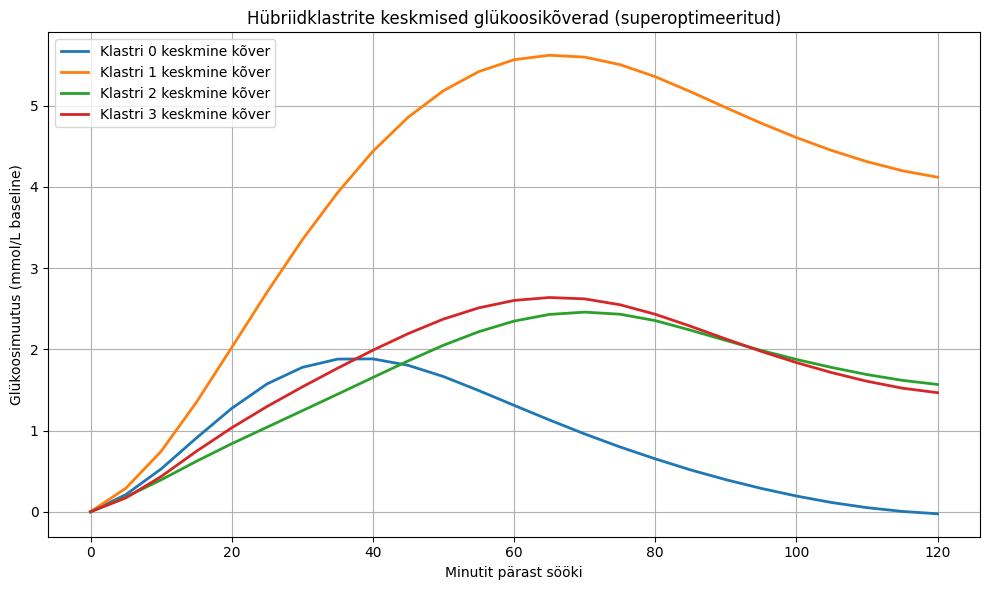


VALMIS! Kõigi hübriidklastrite keskmised glükoosikõverad on joonistatud.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

print("=== SUPEROPTIMEERITUD KLASTRI KESKMISED GLÜKOOSIKÕVERAD ===")

# -------------------------------------------------------
# 1) PREPROCESSING — TEEME SEDA AINULT ÜKS KORD PÄTSIENDI KOHTA
# -------------------------------------------------------

print("-> Eeltöötlen patsientide glükoosiandmed...")

preprocessed = {}

for pid, pdf in df.groupby("PtID"):
    pdf = (
        pdf.sort_values("DataDtTm")
        .drop_duplicates(subset=["DataDtTm"], keep="last")
        .assign(gl=lambda x: x["CGM"] / 18.0)
        .set_index("DataDtTm")
        .sort_index()
    )
    preprocessed[pid] = pdf["gl"]   # ainult gl oleks vaja


# -------------------------------------------------------
# 2) ÜLIKIIRE KÕVERA EKSTRAKTSIOON FUNKTSIOON
# -------------------------------------------------------

from pandas import Timedelta

def fast_curve(gl_series, start_time, window=120):
    """
    Tagastab episoodi glükoosikõvera (25 punkti, 5-min intervalliga)
    ülikiire NumPy/Pandas reindex meetodil.
    """
    start = pd.to_datetime(start_time)
    end = start + Timedelta(minutes=window)

    # Kiire 5-min ajaruudustik
    ti = pd.date_range(start=start, end=end, freq="5min")

    # Reindex + interpolatsioon
    values = gl_series.reindex(ti).interpolate().to_numpy()

    if len(values) != 25 or np.isnan(values).any():
        return None

    baseline = values[0]
    return values - baseline   # baseline-normaliseeritud kõver


# -------------------------------------------------------
# 3) ARVUTA KÕVERAD KLASTRI KAUPA
# -------------------------------------------------------

print("-> Arvutan episoodikõverad (ülikiire meetod)...")

cluster_curves = {cl: [] for cl in sorted(episodes["hybrid_cluster"].unique())}

for idx, row in tqdm(episodes.iterrows(), total=len(episodes)):
    pid = row["PtID"]
    start = row["start"]
    cl = row["hybrid_cluster"]

    curve = fast_curve(preprocessed[pid], start)
    if curve is not None:
        cluster_curves[cl].append(curve)


# -------------------------------------------------------
# 4) ARVUTA KLASTRI KESKMISED KÕVERAD
# -------------------------------------------------------

print("-> Arvutan keskmised kõverad klastrite kaupa...")

cluster_avg_curves = {
    cl: np.mean(np.vstack(curves), axis=0)
    for cl, curves in cluster_curves.items()
    if len(curves) > 0
}


# -------------------------------------------------------
# 5) JOONISTA
# -------------------------------------------------------

print("\n-> Joonistan graafiku...")

plt.figure(figsize=(10, 6))

x = np.arange(25) * 5  # minutid

colors = ["blue", "red", "green", "purple", "orange", "black"]

for i, (cl, avg) in enumerate(cluster_avg_curves.items()):
    plt.plot(x, avg, label=f"Klastri {cl} keskmine kõver", linewidth=2)

plt.xlabel("Minutit pärast sööki")
plt.ylabel("Glükoosimuutus (mmol/L baseline)")
plt.title("Hübriidklastrite keskmised glükoosikõverad (superoptimeeritud)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nVALMIS! Kõigi hübriidklastrite keskmised glükoosikõverad on joonistatud.")



Proovida mõõdikuid külge saada, milline parim klastrite arv
Proovida aru saada mille järgi paneb patseindi mis klastrisse


🔍 PATSIENDI ANALÜÜS: 3

📌 PATSIENDI KLASTER: 0
   (Põhineb 486 episoodil)

📈 KESKMISED NÄITAJAD:
   • Amplituud: 3.63 mmol/L
   • Tippuaeg: 56.5 min
   • Tõusukiirus: 0.067 mmol/L/min
   • Kestus: 63.5 min

🍽️ EPISOODIDE KLASTRITE JAOTUS:
   • Klaster 0: 39 episoodi (8.0%)
   • Klaster 1: 78 episoodi (16.0%)
   • Klaster 2: 207 episoodi (42.6%)
   • Klaster 3: 162 episoodi (33.3%)

⏰ AJASTUSE ANALÜÜS:
   • Episoode päevas (keskm.): 2.6
   • Kõige sagedasemad tunnid:
      - Kell 07:00: 30 episoodi
      - Kell 08:00: 33 episoodi
      - Kell 12:00: 31 episoodi

📊 GLÜKOOSI PÜSIVUS KÕRGEL:
   • Keskmine aeg kõrgel: 103.2 min
   • Mediaan: 120.0 min
   • Pikaajaline kõrgus (≥2h): 53.1%
   • Taastumiskiirus:
      - Aeglane (≥60min): 459 episoodi (94.4%)
      - Kiire (<60min): 27 episoodi (5.6%)

💡 TÕLGENDUS:
   Hea glükoosikontroll - väikesed, aeglased tõusud
   Amplituud on SARNANE klastri keskmisega


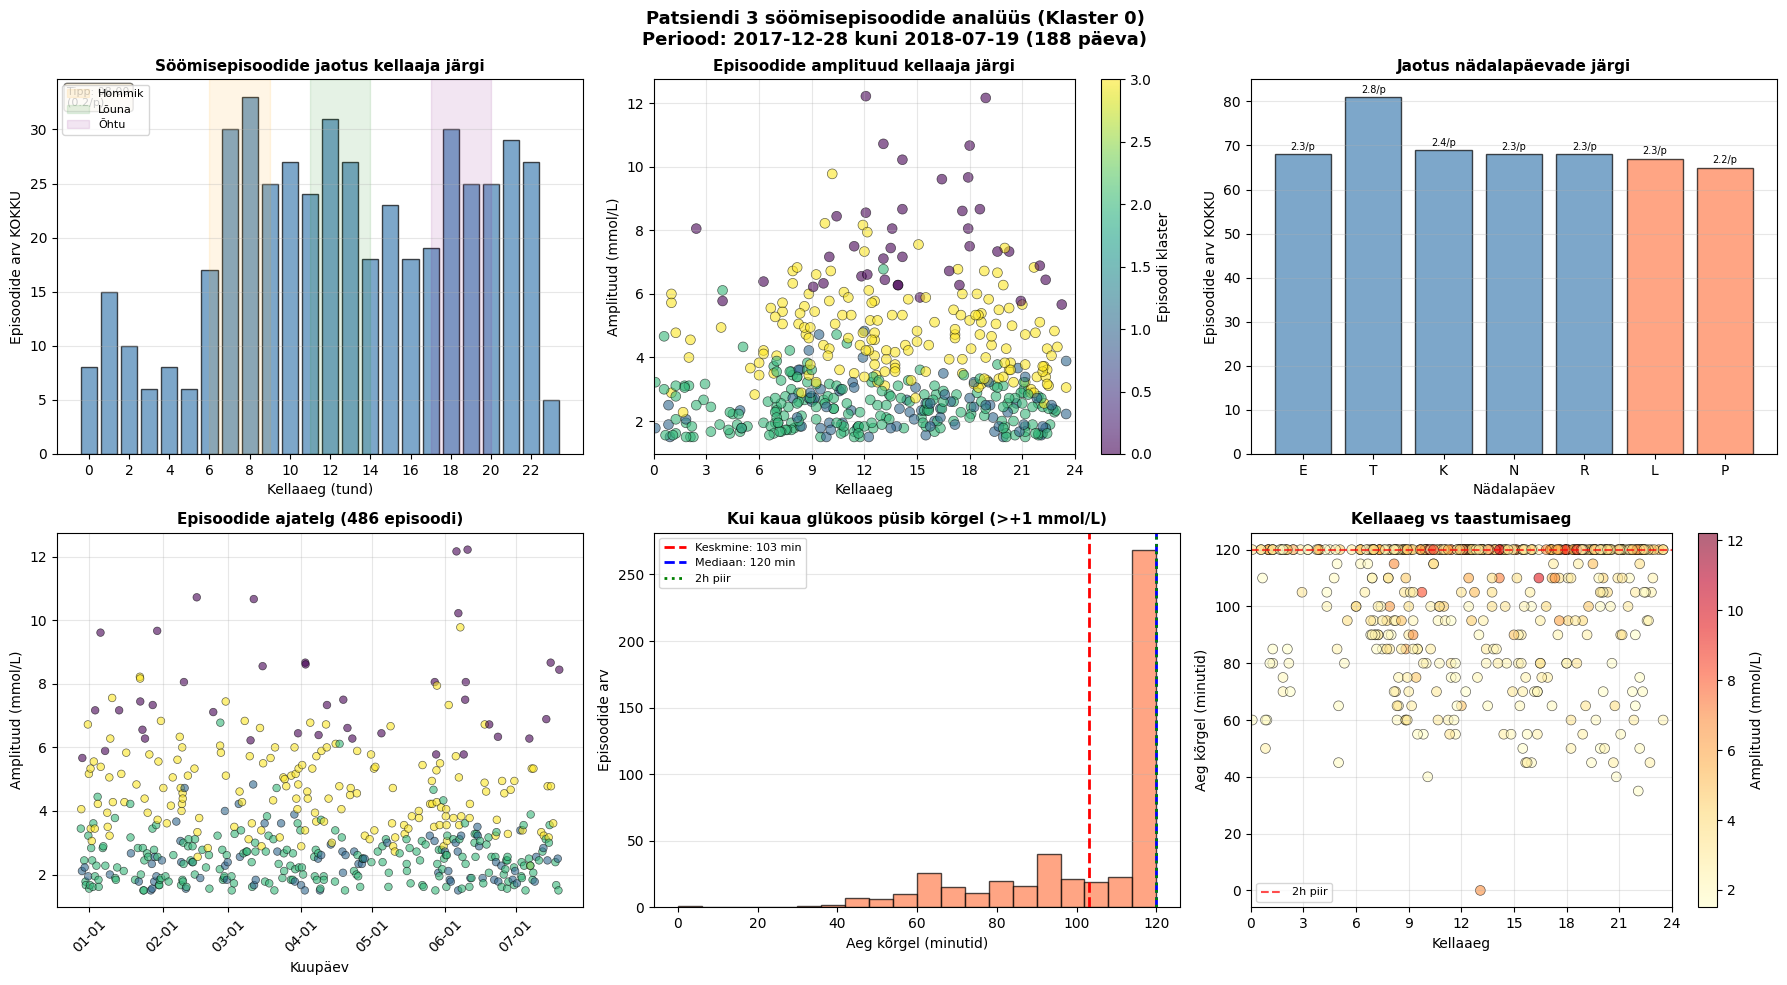

In [ ]:
# Vali üks patsient
patient_id = 3

# Analüüsi teda
result = predict_patient_cluster(patient_id)

Mida episodes esindab?

See on kõik episoodid, mis võivad olla:

* toitumisest tingitud glükoositõusud

* hormonaalsed tõusud

* stressi tõusud

* insuliinipuuduse aeglased tõusud

* sensorimüra

* öised “õrnad” tõusud

Alles pärast klassifitseerimist saab öelda, mis on toitumine ja mis mitte.

In [ ]:
episodes.head()

,PtID,start,peak_time,fall_time,amplitude,rise_slope,duration
0,1,2017-12-12 01:09:25,85.000000,100.000000,0.500000,0.005882,100.000000
1,1,2017-12-12 03:49:25,110.000000,120.000000,1.222222,0.011111,120.000000
2,1,2017-12-12 04:24:24,75.016667,85.016667,0.722222,0.009627,85.016667
3,1,2017-12-12 04:49:25,50.000000,60.000000,0.388889,0.007778,60.000000
4,1,2017-12-12 10:04:24,115.000000,125.000000,2.166667,0.018841,125.000000


2 klastrit

Klastri 0 episoodide arv: 195675


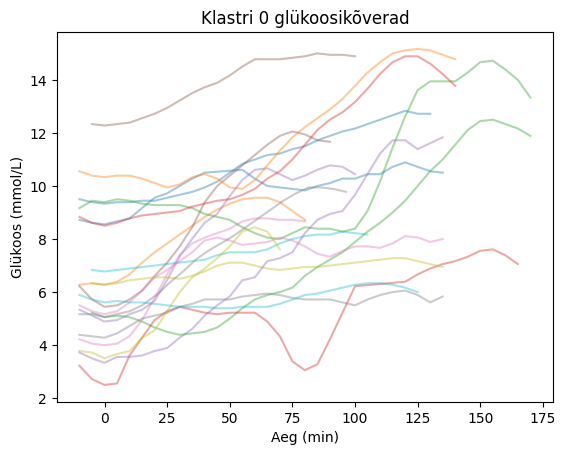

Klastri 1 episoodide arv: 207045


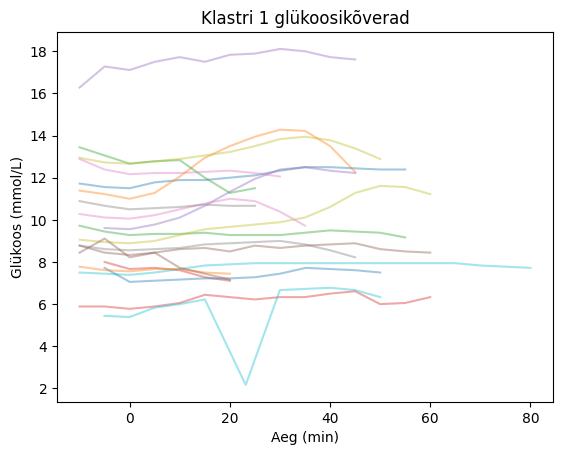

Klastri 2 episoodide arv: 0


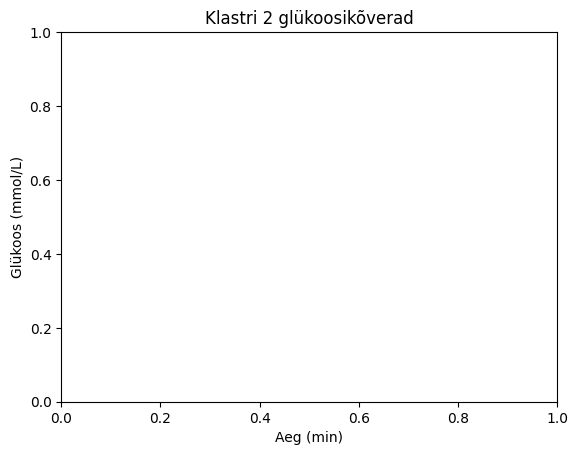

Klastri 3 episoodide arv: 0


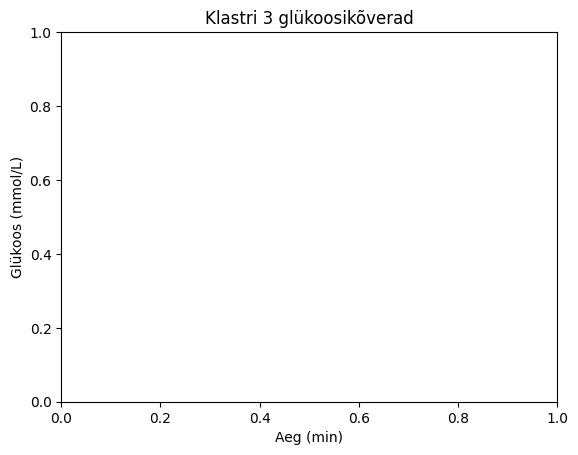

In [ ]:
def plot_cluster_curve(cluster_id):
    eps = episodes[episodes['cluster'] == cluster_id]
    print(f"Klastri {cluster_id} episoodide arv:", len(eps))

    for i, row in eps.sample(min(20, len(eps))).iterrows():
        pt = row['PtID']
        start = row['start']

        # võta patsiendi andmed
        g = df[df['PtID'] == pt].copy()
        g['minute'] = (g['DataDtTm'] - start).dt.total_seconds() / 60

        window = g[(g['minute'] >= -10) & (g['minute'] <= row['duration'] + 10)]
        plt.plot(window['minute'], window['CGM']/18, alpha=0.4)

    plt.title(f"Klastri {cluster_id} glükoosikõverad")
    plt.xlabel("Aeg (min)")
    plt.ylabel("Glükoos (mmol/L)")
    plt.show()

# Näiteks:
plot_cluster_curve(0)
plot_cluster_curve(1)
plot_cluster_curve(2)
plot_cluster_curve(3)


Text(0.5, 1.0, 'Klastri 0 keskmine glükoosikõver')

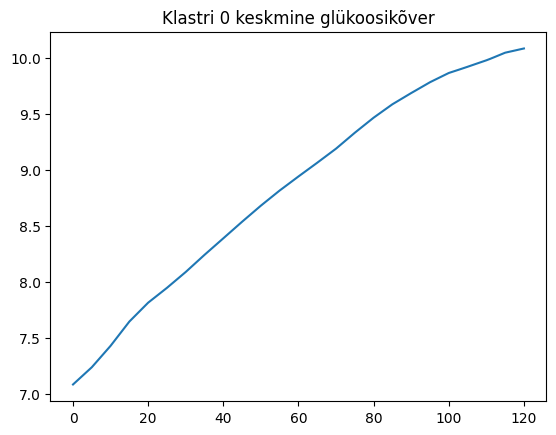

In [ ]:
def get_cluster_average_curve(cluster_id, window=120):
    curves = []

    eps = episodes[episodes['cluster'] == cluster_id].sample(500)

    for _, row in eps.iterrows():
        pt = row['PtID']
        start = row['start']

        g = df[df['PtID'] == pt].copy()
        g['minute'] = (g['DataDtTm'] - start).dt.total_seconds()/60

        w = g[(g['minute'] >= 0) & (g['minute'] <= window)]
        y = w.set_index('minute')['CGM']/18

        # interpoleerime 1-minutilise sammuga
        idx = np.arange(0, window+1)
        curve = np.interp(idx, y.index, y.values)
        curves.append(curve)

    curves = np.vstack(curves)
    return curves.mean(axis=0)


n_clusters = 2
for i in range(1, n_clusters+1):
    avg = get_cluster_average_curve(i)
    plt.figure(figsize=(7,5))
    plt.plot(avg)
    plt.title(f"Klastri {i} keskmine glükoosikõver")
    plt.xlabel("Aeg (min)")
    plt.ylabel("Glükoos (mmol/L)")
    plt.show()



<Axes: xlabel='amplitude', ylabel='Count'>

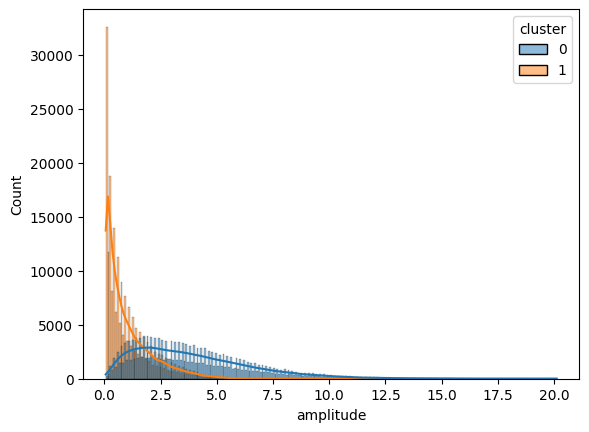

In [ ]:
import seaborn as sns

sns.histplot(data=episodes, x="amplitude", hue="cluster", kde=True)


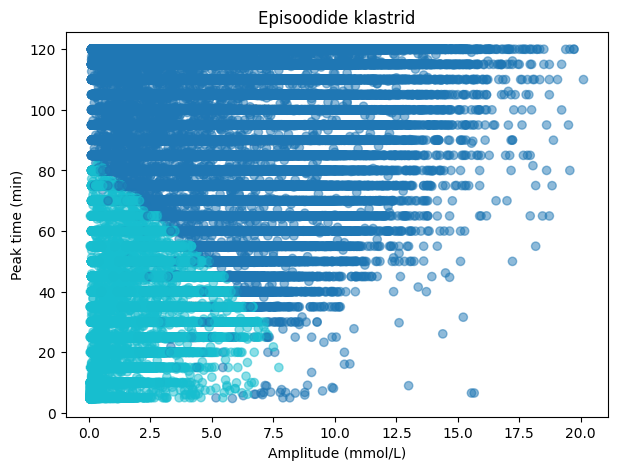

In [ ]:
features = episodes[['amplitude','peak_time','rise_slope','duration']]
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(features)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2).fit(X)
episodes['cluster'] = kmeans.labels_
episodes.groupby("cluster")[['amplitude','peak_time','rise_slope','duration']].mean()

plt.figure(figsize=(7,5))
plt.scatter(episodes['amplitude'], episodes['peak_time'], c=episodes['cluster'], cmap='tab10', alpha=0.5)
plt.xlabel("Amplitude (mmol/L)")
plt.ylabel("Peak time (min)")
plt.title("Episoodide klastrid")
plt.show()


3 klastrit

4 klastrit

In [ ]:
features = episodes[['amplitude','peak_time','rise_slope','duration']]
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(features)

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4).fit(X)
episodes['cluster'] = kmeans.labels_
episodes.groupby("cluster")[['amplitude','peak_time','rise_slope','duration']].mean()


,amplitude,peak_time,rise_slope,duration
cluster,,,,
0,2.341385,102.599926,0.023297,120.257884
1,0.667462,24.025842,0.027549,31.269514
2,7.170095,104.457666,0.070536,121.132966
3,3.562160,40.293168,0.097106,47.443827


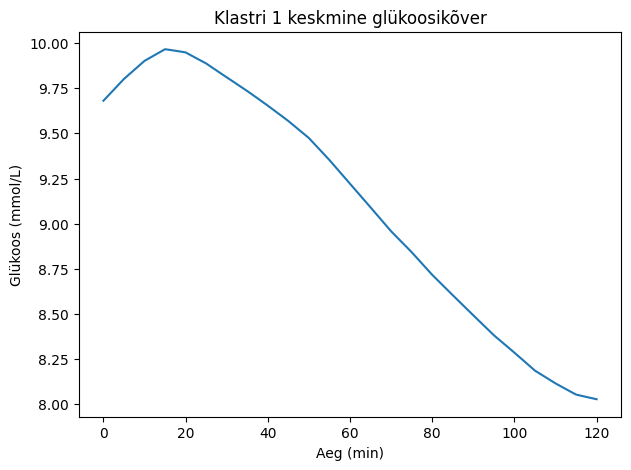

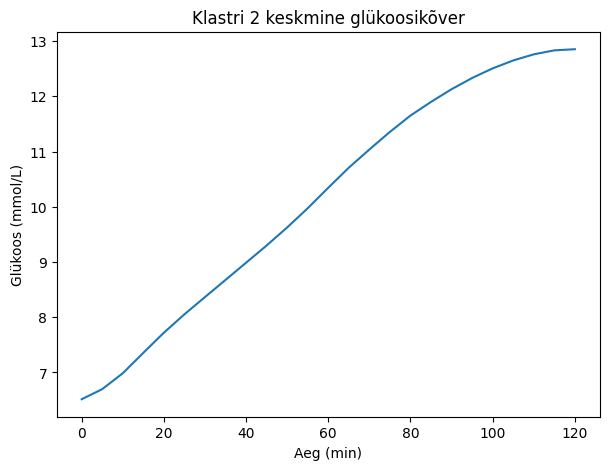

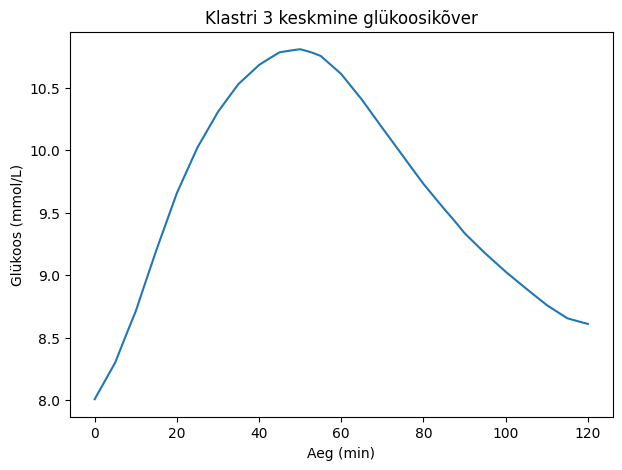

ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
def get_cluster_average_curve(cluster_id, window=120):
    curves = []

    eps = episodes[episodes['cluster'] == cluster_id].sample(500)

    for _, row in eps.iterrows():
        pt = row['PtID']
        start = row['start']

        g = df[df['PtID'] == pt].copy()
        g['minute'] = (g['DataDtTm'] - start).dt.total_seconds()/60

        w = g[(g['minute'] >= 0) & (g['minute'] <= window)]
        y = w.set_index('minute')['CGM']/18

        # interpoleerime 1-minutilise sammuga
        idx = np.arange(0, window+1)
        curve = np.interp(idx, y.index, y.values)
        curves.append(curve)

    curves = np.vstack(curves)
    return curves.mean(axis=0)

n_clusters = 4
for i in range(1, n_clusters+1):
    avg = get_cluster_average_curve(i)
    plt.figure(figsize=(7,5))
    plt.plot(avg)
    plt.title(f"Klastri {i} keskmine glükoosikõver")
    plt.xlabel("Aeg (min)")
    plt.ylabel("Glükoos (mmol/L)")
    plt.show()



5 klastrit